# Análise de Emoções em Letras de Música Brasileira
### Comparação de Três Paradigmas de PLN: Léxico, Encoders Fine-tunados e LLM via Prompting

**Autora:** Sarah Regina Bezerra Sousa · **Disciplina:** PLN · Julho/2026

---
## Resumo executivo dos resultados

**Dados:** MusicSpotsBr → corpus curado de **1.496 músicas** (1950–2024) · gold standard humano de **300 músicas** (7 classes, guia versionado) · rótulos prata por **Qwen2.5-7B local** (1.493/1.496, 2,4 s/música, GPU T4, custo zero de API).

**Taxonomia (7 classes):** alegria · amor · **paixao** | neutro | tristeza · raiva · **saudade** — ancorada em Ekman/GoEmotions com adaptações ao domínio musical brasileiro.

| Método (vs. gold) | macro-F1 (7 cls) | macro-F1 (3 cls) | acc (3 cls) |
|---|---|---|---|
| Qwen2.5-7B (prompt) | **0,473** | **0,670** | **0,756** |
| BERTimbau (fine-tuned) | 0,391 | 0,537 | 0,690 |
| DistilBERT (fine-tuned) | 0,359 | 0,529 | 0,657 |
| NRC-EmoLex (léxico) | 0,109 | 0,368 | 0,457 |

**Achados centrais:**
1. **Herança de vieses na destilação:** o professor (Qwen) tem F1 = 0 para *raiva* — e ambos os alunos herdaram integralmente a cegueira (F1 = 0).
2. **Custo × qualidade:** o BERTimbau entrega ~83% da qualidade do professor com inferência **~130× mais rápida** (0,018 s vs 2,4 s/música).
3. **Saudade (RQ3):** melhor classe do LLM (F1 = 0,634) e estruturalmente inalcançável pelo léxico (F1 = 0; cobertura lexical 29,2%).
4. **Erros concentram-se em distinções finas:** agrupando por valência (3 classes), o desempenho sobe substancialmente — as confusões são intra-família (amor↔paixao, saudade↔tristeza), as mesmas que desafiam anotadores humanos (Kappa humano×LLM = 0,45).

**Organização:** Seções 0–8 = pipeline de dados (Run All seguro, com auditorias). Seções 9–11 = etapas concluídas protegidas por *flags*. Seções 12–14 = baseline, avaliação final e concordância. Seções 15–20 = análises complementares (3 classes, decomposição de erros, ensemble, análise qualitativa).


# Análise de Emoções em Letras de Música Brasileira — Pipeline de Dados

**Projeto:** comparação de três paradigmas de PLN (léxico, encoders fine-tunados, LLM via prompting) para classificação de emoções (7 classes, incl. *saudade*) no corpus MusicSpotsBr.

**Organização deste notebook:** Seções 1–8 formam o pipeline reprodutível de dados (Run All seguro). Seções 9–10 são etapas especiais (anotação interativa e rotulagem prata na GPU), protegidas por *flags* — só executam se você ligar a flag manualmente.

**Artefatos oficiais gerados:** `corpus_oficial_1496.csv`, `gold_amostra_300.csv`, `treino_prata.csv`, `val_prata.csv` (subir como dataset privado após cada mudança).

## 0. Configuração de caminhos
Todos os caminhos de entrada num lugar só. Se algum `FileNotFoundError` aparecer, rode a célula do `os.walk` e cole aqui o caminho impresso.

In [1]:
# ---------------- CONFIG (ajuste aqui, e só aqui) ----------------
RAW_CSV   = "/kaggle/input/datasets/vitoriafirmino/musicspotsbr-popular-brazilian-lyrics-on-spotify/spotify-famosas.csv"
PRATA_CSV = "/kaggle/input/datasets/sarahreginadev/prata-oficial-emocoes/prata_completa_v1.csv"
GOLD_CSV  = "/kaggle/input/datasets/sarahreginadev/fonte-oficial-emocoes/gold_amostra_300.csv"  # usado na Seção 9


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for f in filenames:
        print(os.path.join(dirname, f))

/kaggle/input/datasets/vitoriafirmino/musicspotsbr-popular-brazilian-lyrics-on-spotify/spotify-famosas.csv
/kaggle/input/datasets/sarahreginadev/berts/pred_gold_distilbert.csv
/kaggle/input/datasets/sarahreginadev/berts/pred_gold_bertimbau.csv
/kaggle/input/datasets/sarahreginadev/manual-gold/gold_300_v1.csv
/kaggle/input/datasets/sarahreginadev/manual-gold/gold_amostra_300(1).csv
/kaggle/input/datasets/sarahreginadev/corpus-limpo/corpus_oficial_1496.csv
/kaggle/input/datasets/sarahreginadev/nrc-vl/NRC-Emotion-Lexicon-ForVariousLanguages.txt
/kaggle/input/datasets/sarahreginadev/prata-oficial-emocoes/val_prata.csv
/kaggle/input/datasets/sarahreginadev/prata-oficial-emocoes/prata_completa_v1.csv
/kaggle/input/datasets/sarahreginadev/prata-oficial-emocoes/treino_prata.csv
/kaggle/input/datasets/sarahreginadev/nrc-gold/pred_gold_nrc.csv


## 1. Carga e inspeção do dataset bruto
1.627 registros, 6 colunas, sem nulos (verificado).

In [3]:
import pandas as pd

CAMINHO = RAW_CSV
df = pd.read_csv(CAMINHO)

print(df.shape)          # quantas linhas e colunas
print(df.columns.tolist())  # nomes reais das colunas
df.head(3)

(1627, 6)
['Nome da Música', 'Nome do Artista', 'Ano de Lançamento', 'Gênero Musical', 'Letra da Música', 'Playlist']


,Nome da Música,Nome do Artista,Ano de Lançamento,Gênero Musical,Letra da Música,Playlist
0,Carolina,Seu Jorge,2014,MPB,Carolina é uma menina bem difícil de esquecer ...,Top Hits de 2001
1,Epitáfio,Titãs,2001,Rock,Devia ter amado mais Ter chorado mais Ter vist...,Top Hits de 2001
2,Lugar Ao Sol,Charlie Brown Jr.,2001,Rock,"Que bom viver, como é bom sonhar E o que ficou...",Top Hits de 2001


In [4]:
print(df.info())            # tipos de cada coluna
print(df.isna().sum())      # nulos por coluna
print(df.duplicated().sum())  # linhas 100% idênticas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1627 entries, 0 to 1626
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Nome da Música     1627 non-null   object
 1   Nome do Artista    1627 non-null   object
 2   Ano de Lançamento  1627 non-null   int64 
 3   Gênero Musical     1627 non-null   object
 4   Letra da Música    1627 non-null   object
 5   Playlist           1627 non-null   object
dtypes: int64(1), object(5)
memory usage: 76.4+ KB
None
Nome da Música       0
Nome do Artista      0
Ano de Lançamento    0
Gênero Musical       0
Letra da Música      0
Playlist             0
dtype: int64
0


## 2. Padronização de colunas
Nomes curtos, sem espaço/acento — usados em todo o restante.

In [5]:
df = df.rename(columns={
    "Nome da Música": "titulo",
    "Nome do Artista": "artista",
    "Ano de Lançamento": "ano",
    "Gênero Musical": "genero",
    "Letra da Música": "letra",
    "Playlist": "playlist",
})
df.columns.tolist()

['titulo', 'artista', 'ano', 'genero', 'letra', 'playlist']

## 3. Limpeza
Inspeção do texto cru → filtros de linha (tamanho, duplicatas) → limpeza conservadora do texto (preserva acentos/pontuação) → recorte temporal 1950–2024.

In [6]:
print(repr(df["letra"].iloc[0][:300]))
print("---")
print(repr(df["letra"].iloc[500][:300]))
print("---")
print(repr(df["letra"].iloc[1200][:300]))

'Carolina é uma menina bem difícil de esquecer Andar bonito e um brilho no olhar Tem um jeito adolescente que me faz enlouquecer E um molejo que eu não vou te enganar Maravilha feminina, meu docinho de pavê Inteligente, ela é muito sensual Te confesso que estou apaixonado por você Ô, Carolina, isso é'
---
'Quando Deus te desenhou, ele tava namorando Quando Deus te desenhou, ele tava namorando Na beira do mar, na beira do mar do amor Na beira do mar, na beira do mar do amor Papai do céu na hora de fazer você Ele deve ter caprichado pra valer Botou muita pureza no seu coração E a sua humildade fez chama'
---
"Quando olhei a terra ardendo Qual fogueira de São João Eu perguntei a Deus do céu, ai Por que tamanha judiação? Que braseiro, que fornalha Nem um pé de plantação Por falta d'água, perdi meu gado Morreu de sede meu alazão Por falta d'água, perdi meu gado Morreu de sede meu alazão Inté mesmo a asa bra"


In [7]:
n0 = len(df)
print(f"Início: {n0}")

# 1. Garantia contra letras vazias (sabemos que não há nulos, fica por robustez)
df = df.dropna(subset=["letra"])

# 2. Letras curtas demais (instrumentais ou erro de coleta)
df = df[df["letra"].str.len() >= 100]
print(f"Após filtro de tamanho: {len(df)} (removidas {n0 - len(df)})")

# 3. Duplicatas reais: mesma música em playlists diferentes
n1 = len(df)
df["chave"] = (df["artista"].str.lower().str.strip() + " | " +
               df["titulo"].str.lower().str.strip())
df = df.drop_duplicates(subset="chave", keep="first").drop(columns="chave")
print(f"Após deduplicação: {len(df)} (removidas {n1 - len(df)})")

Início: 1627
Após filtro de tamanho: 1625 (removidas 2)
Após deduplicação: 1515 (removidas 110)


In [8]:
import re

def limpar_letra(t):
    t = re.sub(r"\[.*?\]", " ", t)                          # [Refrão], [Verso 1]
    t = re.sub(r"\(\s*\d+\s*[xX]\s*\)", " ", t)             # (2x), (4X)
    t = re.sub(r"\s+", " ", t)                              # espaços/tabs/quebras múltiplos
    return t.strip()

antes = df["letra"].iloc[0]
df["letra"] = df["letra"].apply(limpar_letra)
print("ANTES :", repr(antes[:200]))
print("DEPOIS:", repr(df["letra"].iloc[0][:200]))

ANTES : 'Carolina é uma menina bem difícil de esquecer Andar bonito e um brilho no olhar Tem um jeito adolescente que me faz enlouquecer E um molejo que eu não vou te enganar Maravilha feminina, meu docinho de'
DEPOIS: 'Carolina é uma menina bem difícil de esquecer Andar bonito e um brilho no olhar Tem um jeito adolescente que me faz enlouquecer E um molejo que eu não vou te enganar Maravilha feminina, meu docinho de'


In [9]:
df = df[(df["ano"] >= 1950) & (df["ano"] <= 2024)]
df["decada"] = (df["ano"] // 10 * 10).astype(int)

print(f"Após recorte 1950–2024: {len(df)}")
print(df["decada"].value_counts().sort_index())

Após recorte 1950–2024: 1514
decada
1950     38
1960     52
1970     99
1980    108
1990    112
2000    136
2010    150
2020    819
Name: count, dtype: int64


## 4. Remoção de sets / medleys / pot-pourris
Faixas que concatenam múltiplas músicas são incompatíveis com emoção única por letra. **Esta célula precisa vir ANTES da criação do `id`.** Esperado: 18 removidas (1.514 → 1.496).

In [10]:
padrao = r"\bset\b|\bmedley\b|\bpot-?pourri\b"

# Diagnóstico: quais serão removidas
suspeitas = df[df["titulo"].str.contains(padrao, case=False, regex=True)]
print(f"Encontradas: {len(suspeitas)}")
print(suspeitas[["titulo", "artista", "ano"]].to_string(index=False))

# Filtro
n2 = len(df)
df = df[~df["titulo"].str.contains(padrao, case=False, regex=True)]
print(f"\nApós remoção de sets/medleys: {len(df)} (removidas {n2 - len(df)})")

Encontradas: 18
                                                                                    titulo              artista  ano
Pot-Pourri: Melhor Eu Ir / Ligando Os Fatos / Sonho de Amor / Deixa Eu Te Querer - Ao Vivo   Grupo Menos É Mais 2020
                                                                     THE BOX MEDLEY FUNK 2              THE BOX 2024
                                                                             Set Dj Gm 6.0                Dj GM 2023
                                                                            Set Dj Boy 3.0               DJ BOY 2023
                                                                       Set Wesley Alemão 2 MC Paulin da Capital 2024
                                                                    Set Tatuapé Conceito 3                Dj GM 2023
                                                                        Set Nino Abravanel           MC Ryan SP 2024
                                                

## 5. Consolidação oficial — id canônico
Último ponto do funil: `reset_index` + `id`. **Nenhum filtro pode existir depois desta célula.** O assert trava o notebook se a contagem não bater.

In [11]:
df = df.reset_index(drop=True)
df["id"] = df.index

assert len(df) == 1496, f"Esperado 1496, veio {len(df)} — algum filtro faltou acima!"

df.to_csv("/kaggle/working/corpus_oficial_1496.csv", index=False)
print(f"SALVO: corpus_oficial_1496.csv ({len(df)} músicas, ids 0–{df['id'].max()})")
print(df["decada"].value_counts().sort_index())

SALVO: corpus_oficial_1496.csv (1496 músicas, ids 0–1495)
decada
1950     38
1960     52
1970     99
1980    108
1990    112
2000    135
2010    149
2020    803
Name: count, dtype: int64


## 6. Verificações do corpus final
Distribuição de comprimentos (letras completas, não truncadas na fonte) e maiores letras (raps longos legítimos após remoção dos sets).

In [12]:
print(df["letra"].str.len().describe())
print(df["letra"].str.len().quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

count    1496.000000
mean     1212.220588
std      1057.944582
min       106.000000
25%       591.000000
50%       973.000000
75%      1417.000000
max      8987.000000
Name: letra, dtype: float64
0.05     382.75
0.25     591.00
0.50     973.00
0.75    1417.00
0.95    2746.25
Name: letra, dtype: float64


In [13]:
df.assign(tam=df["letra"].str.len()).nlargest(3, "tam")[["id", "titulo", "artista", "ano", "tam"]]

,id,titulo,artista,ano,tam
1040,1040,Revoada do Tubarão 3,MC Ryan SP,2022,8987
628,628,Pra Roncar Tem que Desbicar,Mc IG,2024,8633
1041,1041,OQIGAP?,Mc IG,2022,8553


## 7. Amostra GOLD (300) — balanceada
Cotas iguais por faixa de época (5×60) com gêneros musicais proporcionais ao corpus **dentro de cada faixa**; ordem de anotação embaralhada. Consequência documentada: gêneros de épocas antigas (MPB) ficam sobre-representados no agregado — preço da análise por época.

In [14]:
import pandas as pd
import numpy as np

# usa o df consolidado na Seção 5 (mesma sessão)
df["faixa"] = pd.cut(df["ano"], bins=[1949, 1979, 1999, 2009, 2019, 2024])

def amostra_proporcional_genero(g, alvo, seed=42):
    """Dentro da faixa de época, distribui o alvo entre gêneros na proporção
    do corpus (método dos maiores restos), e sorteia dentro de cada gênero."""
    cont  = g['genero'].value_counts()
    cotas = cont / cont.sum() * alvo
    base  = np.floor(cotas).astype(int)
    resto = alvo - base.sum()
    for gen in (cotas - base).sort_values(ascending=False).index[:resto]:
        base[gen] += 1
    partes = []
    for gen, n in base.items():
        n = min(n, cont[gen])
        if n > 0:
            partes.append(g[g['genero'] == gen].sample(n, random_state=seed))
    out = pd.concat(partes)
    if len(out) < alvo:  # completa se algum gênero não tinha estoque
        sobra = g[~g.index.isin(out.index)]
        out = pd.concat([out, sobra.sample(alvo - len(out), random_state=seed)])
    return out

gold = (df.groupby("faixa", observed=True)
          .apply(lambda g: amostra_proporcional_genero(g, 60), include_groups=False)
          .reset_index(drop=True))

# Ordem de anotação embaralhada (cansaço não correlaciona com época/gênero)
gold = gold.sample(frac=1, random_state=42).reset_index(drop=True)

assert len(gold) == 300 and gold['id'].is_unique
gold.to_csv("/kaggle/working/gold_amostra_300.csv", index=False)
print("gold_amostra_300.csv salvo (época em cotas, gênero proporcional)")

gold_amostra_300.csv salvo (época em cotas, gênero proporcional)


In [15]:
print("=== ÉPOCA (deve ser ~60 por faixa) ===")
print(gold.groupby(pd.cut(gold['ano'], bins=[1949,1979,1999,2009,2019,2024]), observed=True).size())

print("\n=== GÊNERO: % corpus vs % amostra ===")
comp = pd.DataFrame({
    'corpus_%':  (df['genero'].value_counts(normalize=True) * 100).round(1),
    'amostra_%': (gold['genero'].value_counts(normalize=True) * 100).round(1),
}).fillna(0)
comp['desvio'] = (comp['amostra_%'] - comp['corpus_%']).round(1)
print(comp.sort_values('corpus_%', ascending=False))

print("\n=== ARTISTAS mais presentes na amostra (atenção se >5) ===")
print(gold['artista'].value_counts().head(8))

print("\n=== TAMANHO DA LETRA (mediana corpus vs amostra) ===")
print(f"corpus:  {df['letra'].str.len().median():.0f} | amostra: {gold['letra'].str.len().median():.0f}")

=== ÉPOCA (deve ser ~60 por faixa) ===
ano
(1949, 1979]    60
(1979, 1999]    60
(1999, 2009]    60
(2009, 2019]    60
(2019, 2024]    60
dtype: int64

=== GÊNERO: % corpus vs % amostra ===
              corpus_%  amostra_%  desvio
genero                                   
MPB               18.7       29.7    11.0
Sertanejo         18.6       16.0    -2.6
Funk              15.5        7.7    -7.8
Pagode            15.0       14.7    -0.3
Rock               8.3       13.0     4.7
Forró              4.7        2.3    -2.4
Trap               4.1        1.7    -2.4
Pop                3.7        3.3    -0.4
Piseiro            3.5        1.3    -2.2
Samba              2.3        4.0     1.7
Rap                2.3        2.3     0.0
Arrocha            0.7        0.3    -0.4
Axé                0.7        0.7     0.0
Reggae             0.7        1.7     1.0
Bossa Nova         0.3        0.3     0.0
Choro              0.3        0.3     0.0
Jovem Guarda       0.2        0.3     0.1
Manguebeat  

## 8. Split treino/validação (rótulos prata) + auditoria
90/10 estratificado pela classe prata, com as 300 do gold **excluídas do pool**. A auditoria confere vazamento entre os três conjuntos.

In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sarahreginadev/prata-oficial-emocoes")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/sarahreginadev/prata-oficial-emocoes


In [17]:
from sklearn.model_selection import train_test_split

prata = pd.read_csv(PRATA_CSV)

# Remove as 300 do gold: NUNCA entram em treino nem validação
pool = prata[~prata['id'].isin(gold['id'])].copy()
print(f"Pool de treino: {len(pool)} (esperado ~1193–1196)")

treino, val = train_test_split(
    pool, test_size=0.10, stratify=pool['emocao_prata'], random_state=42)

treino.to_csv("/kaggle/working/treino_prata.csv", index=False)
val.to_csv("/kaggle/working/val_prata.csv", index=False)
print(f"Treino: {len(treino)} | Validação: {len(val)}")
print("\nDistribuição no treino:");   print(treino['emocao_prata'].value_counts())
print("\nDistribuição na validação:"); print(val['emocao_prata'].value_counts())

Pool de treino: 1194 (esperado ~1193–1196)
Treino: 1074 | Validação: 120

Distribuição no treino:
emocao_prata
alegria     308
paixao      227
tristeza    176
saudade     153
amor        138
neutro       43
raiva        29
Name: count, dtype: int64

Distribuição na validação:
emocao_prata
alegria     34
paixao      26
tristeza    20
saudade     17
amor        15
neutro       5
raiva        3
Name: count, dtype: int64


In [18]:
g = set(gold['id']); t = set(treino['id']); v = set(val['id'])
problemas = []
if g & t: problemas.append("VAZAMENTO: gold ∩ treino")
if g & v: problemas.append("VAZAMENTO: gold ∩ validação")
if t & v: problemas.append("VAZAMENTO: treino ∩ validação")
if len(g) != 300: problemas.append(f"gold={len(g)}")
print("PROBLEMAS:", problemas if problemas else "nenhum — APROVADO ✓")
print(f"gold={len(g)} treino={len(t)} val={len(v)} total={len(g)+len(t)+len(v)}")

PROBLEMAS: nenhum — APROVADO ✓
gold=300 treino=1074 val=120 total=1494


In [19]:
# ---------- AUDITORIA DE INTEGRIDADE (carimbo final do pipeline) ----------
padrao = r"\bset\b|\bmedley\b|\bpot-?pourri\b"
problemas = []

# Corpus: tamanho, ids íntegros, zero sets
if len(df) != 1496: problemas.append(f"corpus={len(df)}")
if not (df['id'].min() == 0 and df['id'].max() == len(df)-1 and df['id'].is_unique):
    problemas.append("ids do corpus não sequenciais/únicos")
if df['titulo'].str.contains(padrao, case=False, regex=True).any():
    problemas.append("sets/medleys remanescentes no corpus")

# Amostra gold: tamanho, zero sets, ids válidos e únicos
if len(gold) != 300: problemas.append(f"gold={len(gold)}")
if gold['titulo'].str.contains(padrao, case=False, regex=True).any():
    problemas.append("sets na amostra gold")
if not gold['id'].isin(df['id']).all(): problemas.append("ids do gold fora do corpus")
if not gold['id'].is_unique: problemas.append("ids repetidos no gold")

# Treino/val: rótulos válidos
CLASSES = {'alegria','amor','paixao','neutro','tristeza','raiva','saudade'}
for nome, conj in [('treino', treino), ('val', val)]:
    if not conj['emocao_prata'].isin(CLASSES).all():
        problemas.append(f"rótulos inválidos em {nome}")

print("INTEGRIDADE:", problemas if problemas else "nenhum problema — APROVADO ✓")


INTEGRIDADE: nenhum problema — APROVADO ✓


## 9. ⚠️ ANOTAÇÃO GOLD (interativa)
Protegida por flag: `input()` travaria o Save & Run All. Para anotar, mude `EXECUTAR_ANOTACAO = True` e rode a célula manualmente. Ao pausar, **baixe o `gold_checkpoint_v1.csv`**.

In [20]:
EXECUTAR_ANOTACAO = False  # mude para True SOMENTE para executar esta etapa

if not EXECUTAR_ANOTACAO:
    print('Anotação desativada (flag False) — célula segura para commit.')
else:
    # =====================================================
    # ANOTAÇÃO GOLD — 300 MÚSICAS — TAXONOMIA v1.0 (7 classes) — v1.1
    # Mudanças da v1.1:
    #   1. Lê a amostra da FONTE OFICIAL (dataset privado, somente leitura)
    #   2. Gate de segurança: recusa rodar se a amostra não tiver 300 músicas
    #   3. Neutro descrito como "último recurso" (sincronizado com guia/prompt)
    # Mantido: letra integral, 7 classes, 'pausa' segura, checkpoint a cada 5,
    # difícil exige observação, lembrete de download.
    # Cole esta célula inteira no notebook 1 e execute.
    # =====================================================
    import pandas as pd
    import os
    from datetime import datetime

    CLASSES = ['alegria', 'amor', 'paixao', 'neutro', 'tristeza', 'raiva', 'saudade']

    AMOSTRA = "/kaggle/working/gold_amostra_300.csv"
    df_amostra = pd.read_csv(AMOSTRA)
    TOTAL = len(df_amostra)
    assert TOTAL == 300, (
        f"AMOSTRA ERRADA: {TOTAL} linhas (esperado 300). "
        "Confira se o dataset fonte-oficial-emocoes está conectado (Add Input) "
        "e se o arquivo é gold_amostra_300.csv.")
    print(f"Amostra OK: {TOTAL} músicas (fonte oficial).")

    checkpoint_file = "/kaggle/working/gold_checkpoint_v1.csv"
    anotacoes = []
    inicio = 0
    if os.path.exists(checkpoint_file):
        df_ck = pd.read_csv(checkpoint_file)
        anotacoes = df_ck.to_dict('records')
        inicio = len(anotacoes)
        print(f"CHECKPOINT: {inicio}/{TOTAL} já anotadas — continuando da {inicio+1}.")
    else:
        print(f"Nova anotação (taxonomia v1.0): 0/{TOTAL}.")

    print("""
    CLASSES v1.0
      POSITIVAS: alegria | amor | paixao
      NEUTRA:    neutro (último recurso)
      NEGATIVAS: tristeza | raiva | saudade
    Regras-chave: R1 saudade=objeto específico perdido; R4 vínculo->amor,
    desejo físico->paixao; R6 desilusão/arrependimento->tristeza;
    R8 neutro é último recurso.
    Comandos no prompt de emoção: 'pausa' para parar com segurança.
    """)

    for _, row in df_amostra.iloc[inicio:].iterrows():
        n = inicio + 1
        print("=" * 80)
        print(f"MÚSICA {n}/{TOTAL}: {row['titulo']} — {row['artista']} ({row['ano']}, {row['genero']})")
        print("-" * 80)
        print(row['letra'])            # LETRA COMPLETA, sempre
        print("-" * 80)
        print("alegria | amor | paixao | neutro | tristeza | raiva | saudade")

        while True:
            emocao = input("Emoção (ou 'pausa'): ").lower().strip()
            if emocao in CLASSES or emocao == 'pausa':
                break
            print(f"Inválida. Opções: {', '.join(CLASSES)}")
        if emocao == 'pausa':
            break

        while True:
            dificil = input("Difícil? (s/n): ").lower().strip()
            if dificil in ('s', 'n'):
                break
        obs = input("Observação: ").strip()
        if dificil == 's' and not obs:
            obs = input("Difícil exige observação — qual foi a dúvida? ").strip()

        anotacoes.append({
            'id': row['id'], 'titulo': row['titulo'], 'artista': row['artista'],
            'ano': row['ano'], 'genero': row['genero'], 'decada': row['decada'],
            'emocao': emocao, 'dificil': dificil, 'observacao': obs,
            'timestamp': datetime.now().isoformat()
        })
        inicio += 1

        if inicio % 5 == 0:
            pd.DataFrame(anotacoes).to_csv(checkpoint_file, index=False)
            print(f"[checkpoint salvo: {inicio}/{TOTAL}]")

    # Saída (pausa ou fim): salvar e orientar
    pd.DataFrame(anotacoes).to_csv(checkpoint_file, index=False)
    print("=" * 80)
    if inicio >= TOTAL:
        final = pd.DataFrame(anotacoes).drop(columns=['timestamp'])
        final.to_csv("/kaggle/working/gold_300_v1.csv", index=False)
        print(f"ANOTAÇÃO COMPLETA -> /kaggle/working/gold_300_v1.csv")
        print(final['emocao'].value_counts().sort_index())
        print(f"Difíceis: {(final['dificil'] == 's').sum()}")
        print(">>> BAIXE o gold_300_v1.csv e suba como dataset privado <<<")
    else:
        print(f"PAUSADO em {inicio}/{TOTAL}. Checkpoint salvo.")
        print(">>> BAIXE AGORA o gold_checkpoint_v1.csv (painel Output/Data) <<<")
        print("Anotação manual é o ativo mais caro do projeto — não confie só no /working.")

Anotação desativada (flag False) — célula segura para commit.


## 10. ⚠️ RÓTULOS PRATA — LLM local (CONCLUÍDO em 13/07)
1.493/1.496 válidas, 2,4 s/música na T4, ~60 min. Mantido para reprodutibilidade; protegido por flag (exige GPU). Requer: `!pip install -q -U transformers accelerate bitsandbytes` + restart do kernel.

In [21]:
EXECUTAR_PRATA = False  # mude para True SOMENTE para executar esta etapa

if not EXECUTAR_PRATA:
    print('Prata desativada (flag False) — já concluída; célula segura para commit.')
else:
    # =====================================================
    # RÓTULOS PRATA — LLM LOCAL (Qwen2.5-7B-Instruct, 4-bit) — v1.1
    # Zero API, zero quota. Roda na GPU do Kaggle.
    #
    # SETUP (uma vez):
    #   1. Settings do notebook: Accelerator = GPU T4 x2 (ou P100), Internet ON
    #   2. Célula: !pip install -q -U transformers accelerate bitsandbytes
    #   3. Dataset privado *fonte-oficial-emocoes* conectado (Add Input)
    #
    # GATE DE SEGURANÇA: recusa rodar se o corpus não tiver 1.496 linhas.
    # Tempo estimado: ~2–3h (sequencial). Checkpoint a cada 25.
    # =====================================================

    import pandas as pd
    import os, json, re, time, torch
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

    # ---------- CONFIG (caminhos oficiais) ----------
    MODELO     = "Qwen/Qwen2.5-7B-Instruct"
    CORPUS     = "/kaggle/working/corpus_oficial_1496.csv"
    CHECKPOINT = "/kaggle/working/prata_local_checkpoint_v1.csv"
    CLASSES = {'alegria','amor','paixao','neutro','tristeza','raiva','saudade'}
    N_ESPERADO = 1496   # gate: versão canônica do corpus

    SYSTEM = "Você é um anotador de emoções em letras de música brasileira. Responda apenas com JSON válido."

    PROMPT = """Leia a letra completa e atribua UMA ÚNICA emoção predominante — a que domina
    a música como um todo (refrão e desfecho pesam mais que versos isolados).
    Classifique a emoção expressa pela letra (do eu-lírico), não a reação do ouvinte.

    CLASSES (7):
    - alegria: celebração, euforia, contentamento geral, festa, gratidão pela
      vida; sem destinatário específico do afeto.
    - amor: afeto e vínculo direcionados a alguém; declaração, carinho, devoção,
      romance. O centro é a ligação afetiva.
    - paixao: desejo físico, atração, sensualidade, sedução. O centro é o corpo
      e o querer, não o vínculo.
    - neutro: letra narrativa, descritiva ou reflexiva sem emoção dominante
      (último recurso).
    - tristeza: dor, sofrimento, lamento, solidão, melancolia; inclui desilusão
      (decepção) e arrependimento (pesar pelo que fez ou deixou de fazer).
    - raiva: indignação, revolta, protesto, agressividade, desprezo, vingança;
      inclui repulsa.
    - saudade: falta de um objeto ESPECÍFICO perdido ou distante (pessoa, lugar,
      época), lembrado com afeto.

    REGRAS DE DESEMPATE (nesta ordem):
    1. saudade vs tristeza: há objeto específico perdido sendo lembrado com
       afeto? saudade. Sofrimento difuso e presente, sem objeto de memória? tristeza.
    2. saudade vs amor: objeto do afeto perdido/distante/no passado? saudade.
       Presente ou ao alcance? amor.
    3. amor vs alegria: afeto direcionado a alguém? amor. Contentamento geral
       sem destinatário? alegria.
    4. amor vs paixao: centro no vínculo/afeto? amor. Centro no desejo/atração
       física? paixao. Os dois juntos com vínculo presente? amor.
    5. tristeza vs raiva (término/traição): lamento e dor? tristeza. Ataque,
       revolta ou vingança? raiva.
    6. Reflexão sobre a vida com pesar ou arrependimento? tristeza. Reflexão sem
       carga emocional dominante? neutro.
    7. Letra centrada em medo ou surpresa: classifique pelo tom emocional
       resultante (angústia/sofrimento -> tristeza; confronto -> raiva; sem carga -> neutro).
    8. neutro apenas quando nenhuma emoção é claramente predominante.

    Responda APENAS com JSON no formato:
    {"emocao": "<alegria|amor|paixao|neutro|tristeza|raiva|saudade>"}

    LETRA:
    <<<
    {letra}
    >>>"""

    # ---------- GATE + DADOS ----------
    df = pd.read_csv(CORPUS)
    assert len(df) == N_ESPERADO, (
        f"CORPUS ERRADO: {len(df)} linhas (esperado {N_ESPERADO}). "
        "Confira se o dataset fonte-oficial-emocoes está conectado (Add Input) "
        "e se o arquivo é corpus_oficial_1496.csv.")
    print(f"Corpus OK: {len(df)} músicas (fonte oficial).")

    feitos = {}
    if os.path.exists(CHECKPOINT):
        ck = pd.read_csv(CHECKPOINT)
        ck = ck[ck['emocao_prata'].isin(CLASSES)]
        feitos = dict(zip(ck['id'], ck['emocao_prata']))
    pendentes = df[~df['id'].isin(feitos.keys())]
    print(f"Concluídas: {len(feitos)} | pendentes: {len(pendentes)}")

    # ---------- MODELO ----------
    print("Carregando modelo (primeira vez baixa ~5 GB, alguns minutos)...")
    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
                             bnb_4bit_quant_type="nf4")
    tok = AutoTokenizer.from_pretrained(MODELO)
    model = AutoModelForCausalLM.from_pretrained(
        MODELO, quantization_config=bnb, device_map="auto")
    model.eval()
    print("Modelo pronto.")

    def classificar(letra):
        msgs = [{"role": "system", "content": SYSTEM},
                {"role": "user", "content": PROMPT.replace("{letra}", str(letra))}]
        texto = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inp = tok(texto, return_tensors="pt", truncation=True, max_length=3500).to(model.device)
        with torch.no_grad():
            out = model.generate(**inp, max_new_tokens=24, do_sample=False,
                                 pad_token_id=tok.eos_token_id)
        resp = tok.decode(out[0][inp['input_ids'].shape[1]:], skip_special_tokens=True)
        m = re.search(r'\{.*?\}', resp, re.DOTALL)
        if not m:
            return None
        try:
            emo = json.loads(m.group(0)).get('emocao', '').lower().strip()
            return emo if emo in CLASSES else None
        except json.JSONDecodeError:
            return None

    # ---------- LOOP ----------
    novos, erros = [], 0
    t0 = time.time()

    for i, (_, row) in enumerate(pendentes.iterrows(), 1):
        emo = classificar(row['letra'])
        if emo:
            novos.append({'id': row['id'], 'emocao_prata': emo})
        else:
            erros += 1

        if i % 25 == 0:
            base = pd.DataFrame([{'id': k, 'emocao_prata': v} for k, v in feitos.items()])
            pd.concat([base, pd.DataFrame(novos)]).to_csv(CHECKPOINT, index=False)
            ritmo = (time.time() - t0) / i
            falta = ritmo * (len(pendentes) - i) / 60
            print(f"{i}/{len(pendentes)} | válidas: {len(novos)} | erros: {erros} "
                  f"| {ritmo:.1f}s/música | ~{falta:.0f} min restantes")

    # ---------- SALVA ----------
    base = pd.DataFrame([{'id': k, 'emocao_prata': v} for k, v in feitos.items()])
    final = pd.concat([base, pd.DataFrame(novos)]) if novos else base
    final.to_csv(CHECKPOINT, index=False)

    print("\n" + "=" * 60)
    print(f"Disparo encerrado: +{len(novos)} válidas | erros: {erros}")
    print(f"TOTAL: {len(final)}/{len(df)}")
    if len(final) >= len(df) - 5:   # tolerância a pouquíssimos erros persistentes
        final.merge(df, on='id').to_csv("/kaggle/working/prata_completa_v1.csv", index=False)
        print("PRATA COMPLETA -> /kaggle/working/prata_completa_v1.csv")
        print(final['emocao_prata'].value_counts().sort_index())
    print(">>> Save Version no notebook + baixe o checkpoint (aba Output) <<<")

Prata desativada (flag False) — já concluída; célula segura para commit.


## 11. Fine-tuning dos encoders (CONCLUÍDO em 15/07)
BERTimbau-base e DistilBERT-multilingual treinados nos rótulos prata (class weights, até 20 épocas com early stopping patience=3, warmup 10%).

**Resultados (validação prata):** BERTimbau macro-F1 **0,669** (parou na época 10; melhor: 7) · DistilBERT **0,501** (época 13; melhor: 10). Custos: 108,9M params/10,7 min vs 135,3M/7,9 min; inferência 0,018 vs 0,010 s/música. Protegido por flag — as predições já estão salvas (`pred_gold_bertimbau.csv`, `pred_gold_distilbert.csv`).

In [22]:
EXECUTAR_TREINO = False  # mude para True SOMENTE para reexecutar esta etapa

if not EXECUTAR_TREINO:
    print('Treino desativado (flag False) — concluído; predições já salvas.')
else:
    import pandas as pd
    import numpy as np
    import os, time, json, torch
    from torch.utils.data import Dataset
    from sklearn.metrics import f1_score, accuracy_score
    from sklearn.utils.class_weight import compute_class_weight
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              Trainer, TrainingArguments, EarlyStoppingCallback)

    # ---------- CONFIG ----------
    TREINO_CSV = "/kaggle/input/datasets/sarahreginadev/prata-oficial-emocoes/treino_prata.csv"
    VAL_CSV    = "/kaggle/input/datasets/sarahreginadev/prata-oficial-emocoes/val_prata.csv"
    CORPUS_CSV = "/kaggle/input/datasets/sarahreginadev/corpus-limpo/corpus_oficial_1496.csv"
    GOLD_CSV   = "/kaggle/input/datasets/sarahreginadev/manual-gold/gold_300_v1.csv"

    MODELOS = {
        "bertimbau":  "neuralmind/bert-base-portuguese-cased",
        "distilbert": "distilbert-base-multilingual-cased",
    }
    CLASSES = sorted(['alegria','amor','paixao','neutro','tristeza','raiva','saudade'])
    id2label = dict(enumerate(CLASSES)); label2id = {v: k for k, v in id2label.items()}

    # ---------- DADOS ----------
    treino = pd.read_csv(TREINO_CSV)
    val    = pd.read_csv(VAL_CSV)
    corpus = pd.read_csv(CORPUS_CSV)
    gold   = pd.read_csv(GOLD_CSV)

    letras = corpus[['id', 'letra']]
    treino = treino.merge(letras, on='id', suffixes=('', '_c'))
    val    = val.merge(letras, on='id', suffixes=('', '_c'))
    gold   = gold.merge(letras, on='id')

    assert len(gold) == 300 and treino['emocao_prata'].isin(CLASSES).all()
    print(f"treino={len(treino)} val={len(val)} gold={len(gold)}")

    y_tr = treino['emocao_prata'].map(label2id).values
    pesos = compute_class_weight('balanced', classes=np.arange(len(CLASSES)), y=y_tr)
    pesos_t = torch.tensor(pesos, dtype=torch.float)

    class DS(Dataset):
        def __init__(self, textos, labels, tok):
            self.enc = tok(list(textos), truncation=True, max_length=512,
                           padding='max_length')
            self.labels = list(labels)
        def __len__(self): return len(self.labels)
        def __getitem__(self, i):
            item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
            item['labels'] = torch.tensor(self.labels[i])
            return item

    class TrainerPonderado(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            loss = torch.nn.functional.cross_entropy(
                outputs.logits, labels, weight=pesos_t.to(outputs.logits.device))
            return (loss, outputs) if return_outputs else loss

    def metricas(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(-1)
        return {"macro_f1": f1_score(labels, preds, average="macro"),
                "accuracy": accuracy_score(labels, preds)}

    def training_args(outdir):
        base = dict(output_dir=outdir, learning_rate=2e-5,
                    per_device_train_batch_size=16, per_device_eval_batch_size=32,
                    num_train_epochs=20, warmup_ratio=0.1, weight_decay=0.01,
                    fp16=True, load_best_model_at_end=True,
                    metric_for_best_model="macro_f1", save_total_limit=1,
                    logging_steps=25, report_to="none", seed=42)
        try:
            return TrainingArguments(eval_strategy="epoch", save_strategy="epoch", **base)
        except TypeError:
            return TrainingArguments(evaluation_strategy="epoch", save_strategy="epoch", **base)

    # ---------- TREINO ----------
    resultados = {}
    for nome, hf_id in MODELOS.items():
        print("\n" + "="*70); print(f"MODELO: {nome} ({hf_id})"); print("="*70)
        tok = AutoTokenizer.from_pretrained(hf_id, force_download=True)
        model = AutoModelForSequenceClassification.from_pretrained(
            hf_id, num_labels=len(CLASSES), id2label=id2label, label2id=label2id,
            force_download=True)

        # GUARDA anti-contaminação: pesos antigos (gamma/beta) derrubam o run
        ruins = [k for k in model.state_dict().keys()
                 if k.endswith('.gamma') or k.endswith('.beta')]
        assert not ruins, f"PESOS EM FORMATO ANTIGO DETECTADOS: {ruins[:3]} — parar!"

        n_params = sum(p.numel() for p in model.parameters())
        ds_tr = DS(treino['letra'], treino['emocao_prata'].map(label2id), tok)
        ds_va = DS(val['letra'],    val['emocao_prata'].map(label2id),    tok)

        trainer = TrainerPonderado(
            model=model, args=training_args(f"/kaggle/working/{nome}"),
            train_dataset=ds_tr, eval_dataset=ds_va, compute_metrics=metricas,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)])

        t0 = time.time(); trainer.train(); t_treino = time.time() - t0
        ev = trainer.evaluate()
        epoca_final = int(trainer.state.epoch)

        ds_gold = DS(gold['letra'], [0]*len(gold), tok)
        t0 = time.time()
        preds = trainer.predict(ds_gold).predictions.argmax(-1)
        t_inf = (time.time() - t0) / len(gold)

        gold_out = gold[['id']].copy()
        gold_out[f'pred_{nome}'] = [id2label[p] for p in preds]
        gold_out.to_csv(f"/kaggle/working/pred_gold_{nome}.csv", index=False)

        resultados[nome] = {
            "params_M": round(n_params/1e6, 1),
            "epocas_treinadas": epoca_final,
            "tempo_treino_min": round(t_treino/60, 1),
            "tempo_inferencia_s_por_musica": round(t_inf, 3),
            "val_macro_f1": round(ev["eval_macro_f1"], 4),
            "val_accuracy": round(ev["eval_accuracy"], 4),
        }
        print(f"\n{nome}: {resultados[nome]}")
        if ev["eval_macro_f1"] < 0.20:
            print("!!! F1 no nível do acaso — NÃO prosseguir, me chamar !!!")

    print("\n" + "="*70)
    print(json.dumps(resultados, indent=2, ensure_ascii=False))
    with open("/kaggle/working/resultados_finetuning.json", "w") as f:
        json.dump(resultados, f, indent=2, ensure_ascii=False)
    print(">>> Save Version + baixar pred_gold_*.csv e resultados_finetuning.json <<<")

Treino desativado (flag False) — concluído; predições já salvas.


## 12. Baseline léxico — NRC-EmoLex PT (paradigma 1)
Mapeamento: joy→alegria; sadness+fear→tristeza; anger+disgust→raiva; demais sem correspondente. *amor*, *paixao* e *saudade* são **estruturalmente inalcançáveis** pelo léxico (resultado da RQ3). Cobertura lexical média no gold: **29,2%**.

In [23]:
# =====================================================
# BASELINE LÉXICO — NRC-EmoLex (traduções PT) — paradigma 1
#
# PREPARO (uma vez):
#   1. Baixe o NRC Emotion Lexicon no site oficial (busca:
#      "NRC Emotion Lexicon Saif Mohammad") — o zip contém um arquivo
#      "...ForVariousLanguages.txt" com colunas de tradução (incl. português)
#      e as 10 colunas de afeto (anger, joy, sadness, ...).
#   2. Suba esse .txt como dataset privado no Kaggle e conecte (Add Input).
#   3. Ajuste os caminhos no CONFIG.
#
# Mapeamento p/ a taxonomia (documentar no artigo):
#   joy -> alegria | sadness+fear -> tristeza | anger+disgust -> raiva
#   surprise/anticipation/trust -> sem correspondente (só contam cobertura)
#   amor, paixao, saudade -> ESTRUTURALMENTE inalcançáveis pelo léxico
#   (isto é RESULTADO da RQ3, não defeito)
# Predição: classe de maior contagem; tudo zero ou empate total -> neutro.
# =====================================================

import pandas as pd
import re, unicodedata
from collections import Counter

# ---------- CONFIG ----------
LEXICO_TXT = "/kaggle/input/datasets/sarahreginadev/nrc-vl/NRC-Emotion-Lexicon-ForVariousLanguages.txt"
CORPUS_CSV = "/kaggle/input/datasets/sarahreginadev/corpus-limpo/corpus_oficial_1496.csv"
GOLD_CSV   = "/kaggle/input/datasets/sarahreginadev/manual-gold/gold_300_v1.csv"

MAPA = {"joy": "alegria", "sadness": "tristeza", "fear": "tristeza",
        "anger": "raiva", "disgust": "raiva"}
EMOCOES_NRC = ["anger","anticipation","disgust","fear","joy",
               "sadness","surprise","trust"]

# ---------- LÉXICO ----------
lex = pd.read_csv(LEXICO_TXT, sep="\t")
col_pt = next(c for c in lex.columns if "portug" in c.lower())
print(f"Coluna PT detectada: '{col_pt}' | {len(lex)} entradas")

def norm(w):
    w = str(w).lower().strip()
    return unicodedata.normalize("NFKD", w).encode("ascii","ignore").decode()

# dicionário: palavra_pt_normalizada -> Counter de classes da taxonomia
dic = {}
vocab_pt = set()
for _, r in lex.iterrows():
    w = norm(r[col_pt])
    if not w or w == "nan":
        continue
    vocab_pt.add(w)
    for emo in EMOCOES_NRC:
        if emo in lex.columns and r[emo] == 1 and emo in MAPA:
            dic.setdefault(w, Counter())[MAPA[emo]] += 1
print(f"Palavras PT no léxico: {len(vocab_pt)} | com emoção mapeada: {len(dic)}")

# ---------- CLASSIFICADOR ----------
tok_re = re.compile(r"[a-zà-ÿ]+", re.IGNORECASE)

def classificar(letra):
    tokens = [norm(t) for t in tok_re.findall(str(letra).lower())]
    if not tokens:
        return "neutro", 0.0
    cobertos = [t for t in tokens if t in vocab_pt]
    cont = Counter()
    for t in tokens:
        if t in dic:
            cont.update(dic[t])
    cobertura = len(cobertos) / len(tokens)
    if not cont:
        return "neutro", cobertura
    top = cont.most_common(2)
    if len(top) > 1 and top[0][1] == top[1][1]:   # empate -> neutro
        return "neutro", cobertura
    return top[0][0], cobertura

# ---------- APLICA NO GOLD ----------
corpus = pd.read_csv(CORPUS_CSV)[['id','letra']]
gold = pd.read_csv(GOLD_CSV).merge(corpus, on='id')

res = gold['letra'].apply(classificar)
gold_out = gold[['id']].copy()
gold_out['pred_nrc'] = [r[0] for r in res]
coberturas = [r[1] for r in res]

gold_out.to_csv("/kaggle/working/pred_gold_nrc.csv", index=False)
print(f"\npred_gold_nrc.csv salvo ({len(gold_out)} predições)")
print(f"Cobertura lexical média: {100*sum(coberturas)/len(coberturas):.1f}% "
      f"(Nogueira & Capanema reportaram ~40% — comparar no artigo)")
print("\nDistribuição das predições do léxico:")
print(gold_out['pred_nrc'].value_counts())
print("\nNota estrutural: amor, paixao e saudade têm 0 predições por construção.")


Coluna PT detectada: 'Portuguese' | 14154 entradas
Palavras PT no léxico: 11217 | com emoção mapeada: 2825

pred_gold_nrc.csv salvo (300 predições)
Cobertura lexical média: 29.2% (Nogueira & Capanema reportaram ~40% — comparar no artigo)

Distribuição das predições do léxico:
pred_nrc
tristeza    133
alegria      81
raiva        54
neutro       32
Name: count, dtype: int64

Nota estrutural: amor, paixao e saudade têm 0 predições por construção.


## 13. Avaliação final — 4 métodos × gold (300)
Tabela principal, F1 por classe, 4 matrizes de confusão (PNG+PDF) e tabela custo×qualidade.

=== TABELA PRINCIPAL (vs gold) ===
             método   n  macro_F1  acurácia  kappa
Qwen2.5-7B (prompt) 299     0.473     0.535  0.450
     BERTimbau (ft) 300     0.391     0.453  0.356
    DistilBERT (ft) 300     0.359     0.430  0.316
       NRC (léxico) 300     0.109     0.163  0.052

=== F1 POR CLASSE ===
          n_gold  NRC (léxico)  Qwen2.5-7B (prompt)  BERTimbau (ft)  DistilBERT (ft)
alegria       38         0.286                0.523           0.476            0.442
amor          73         0.000                0.623           0.540            0.599
paixao        47         0.000                0.564           0.557            0.404
neutro        44         0.079                0.444           0.160            0.222
tristeza      35         0.298                0.520           0.452            0.333
raiva         26         0.100                0.000           0.000            0.000
saudade       37         0.000                0.634           0.550            0.513


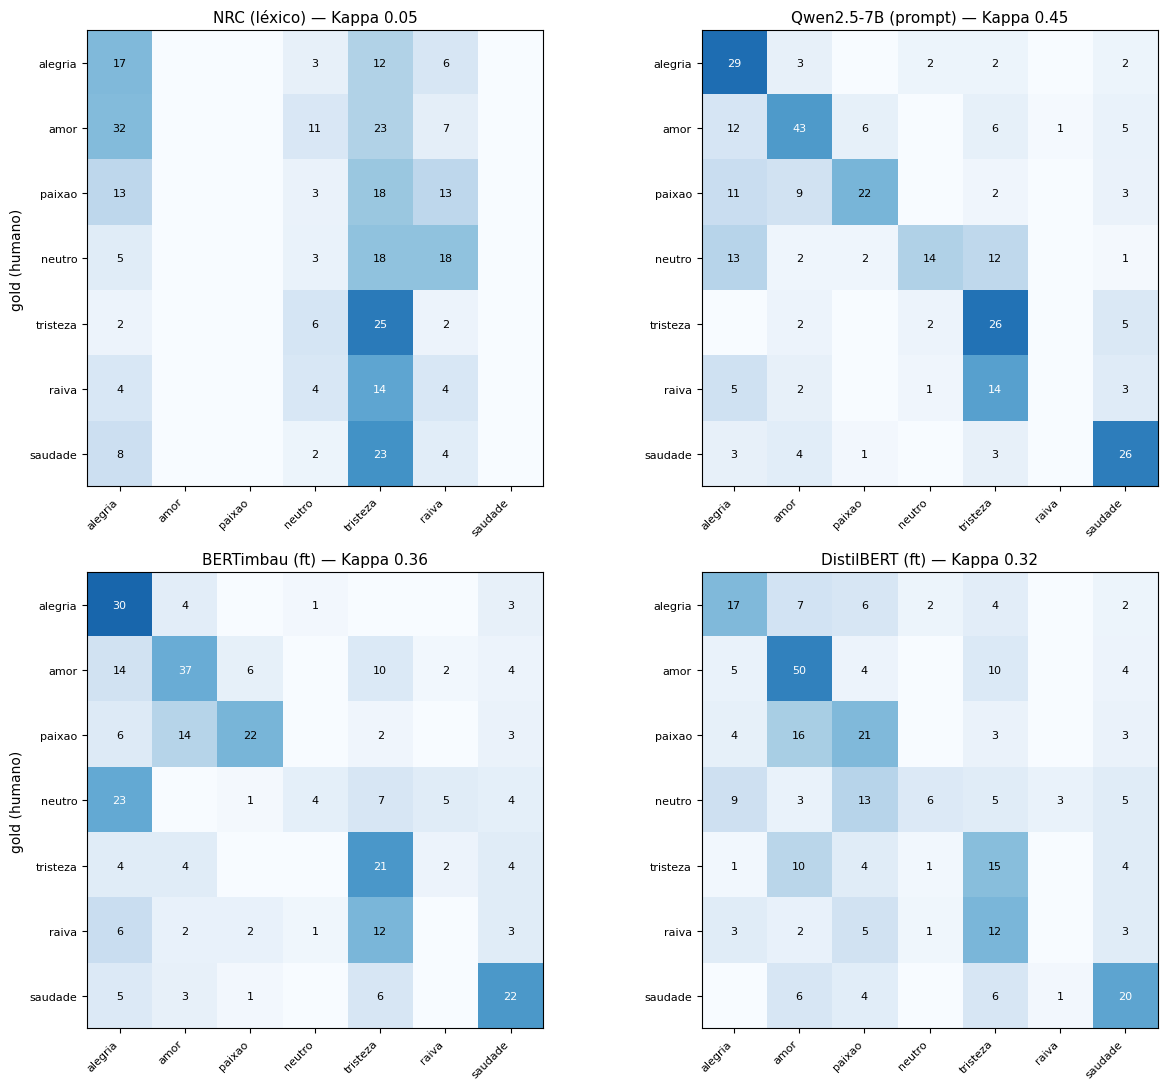


=== CUSTO x QUALIDADE ===
                     macro_F1_gold  params    treino inferencia_s        hardware
NRC (léxico)                 0.109       —         —       <0.001             CPU
Qwen2.5-7B (prompt)          0.473  7.600M         —          2.4  GPU T4 (4-bit)
BERTimbau (ft)               0.391  108.9M  10.7 min        0.018          GPU T4
DistilBERT (ft)              0.359  135.3M   7.9 min        0.010          GPU T4

Arquivos em /kaggle/working: tabela_principal.csv, f1_por_classe.csv,
fig_matrizes_4metodos.(png|pdf), tabela_custo_qualidade.csv
>>> Save Version + baixar tudo <<<


In [24]:
# =====================================================
# AVALIAÇÃO FINAL — os 4 métodos contra o GOLD (300)
#   Paradigma 1: léxico NRC          -> pred_gold_nrc.csv
#   Paradigma 2: BERTimbau (ft)      -> pred_gold_bertimbau.csv
#                DistilBERT (ft)     -> pred_gold_distilbert.csv
#   Paradigma 3: LLM local (Qwen)    -> prata_completa_v1.csv
#
# Gera: tabela principal (macro-F1/acc/Kappa), F1 por classe,
#       4 matrizes de confusão (figura única PNG+PDF), tabela de custo.
# Roda em CPU. Ajuste os caminhos no CONFIG.
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (f1_score, accuracy_score, cohen_kappa_score,
                             confusion_matrix)

# ---------- CONFIG ----------
GOLD_CSV   = "/kaggle/input/datasets/sarahreginadev/manual-gold/gold_300_v1.csv"
PRATA_CSV  = "/kaggle/input/datasets/sarahreginadev/prata-oficial-emocoes/prata_completa_v1.csv"
PRED_BERT  = "/kaggle/input/datasets/sarahreginadev/berts/pred_gold_bertimbau.csv"
PRED_DIST  = "/kaggle/input/datasets/sarahreginadev/berts/pred_gold_distilbert.csv"
PRED_NRC   = "/kaggle/input/datasets/sarahreginadev/nrc-gold/pred_gold_nrc.csv"

CLASSES = ['alegria','amor','paixao','neutro','tristeza','raiva','saudade']

# Custos (preencher com os números reais medidos)
CUSTOS = {
  "NRC (léxico)":        {"params": "—",      "treino": "—",
                          "inferencia_s": "<0.001", "hardware": "CPU"},
  "Qwen2.5-7B (prompt)": {"params": "7.600M", "treino": "—",
                          "inferencia_s": "2.4",    "hardware": "GPU T4 (4-bit)"},
  "BERTimbau (ft)":      {"params": "108.9M", "treino": "10.7 min",
                          "inferencia_s": "0.018",  "hardware": "GPU T4"},
  "DistilBERT (ft)":     {"params": "135.3M", "treino": "7.9 min",
                          "inferencia_s": "0.010",  "hardware": "GPU T4"},
}

# ---------- MONTAGEM ----------
gold = pd.read_csv(GOLD_CSV)[['id','emocao']]
m = (gold
     .merge(pd.read_csv(PRATA_CSV)[['id','emocao_prata']], on='id', how='left')
     .merge(pd.read_csv(PRED_BERT), on='id', how='left')
     .merge(pd.read_csv(PRED_DIST), on='id', how='left')
     .merge(pd.read_csv(PRED_NRC),  on='id', how='left'))

METODOS = {"NRC (léxico)": "pred_nrc",
           "Qwen2.5-7B (prompt)": "emocao_prata",
           "BERTimbau (ft)": "pred_bertimbau",
           "DistilBERT (ft)": "pred_distilbert"}

# ---------- TABELA PRINCIPAL ----------
linhas = []
for nome, col in METODOS.items():
    sub = m.dropna(subset=[col])          # prata tem 1 id sem rótulo
    y, p = sub['emocao'], sub[col]
    linhas.append({
        "método": nome, "n": len(sub),
        "macro_F1": round(f1_score(y, p, average='macro',
                                   labels=CLASSES, zero_division=0), 3),
        "acurácia": round(accuracy_score(y, p), 3),
        "kappa":    round(cohen_kappa_score(y, p), 3),
    })
tab = pd.DataFrame(linhas).sort_values("macro_F1", ascending=False)
print("=== TABELA PRINCIPAL (vs gold) ===")
print(tab.to_string(index=False))
tab.to_csv("/kaggle/working/tabela_principal.csv", index=False)

# ---------- F1 POR CLASSE ----------
f1c = {}
for nome, col in METODOS.items():
    sub = m.dropna(subset=[col])
    f1c[nome] = f1_score(sub['emocao'], sub[col], average=None,
                         labels=CLASSES, zero_division=0).round(3)
f1_classe = pd.DataFrame(f1c, index=CLASSES)
suporte = gold['emocao'].value_counts().reindex(CLASSES)
f1_classe.insert(0, "n_gold", suporte.values)
print("\n=== F1 POR CLASSE ===")
print(f1_classe.to_string())
f1_classe.to_csv("/kaggle/working/f1_por_classe.csv")

# ---------- MATRIZES DE CONFUSÃO (figura 2x2) ----------
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (nome, col) in zip(axes.flat, METODOS.items()):
    sub = m.dropna(subset=[col])
    cm = confusion_matrix(sub['emocao'], sub[col], labels=CLASSES)
    cm_pct = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(7), CLASSES, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(7), CLASSES, fontsize=8)
    k = cohen_kappa_score(sub['emocao'], sub[col])
    ax.set_title(f"{nome} — Kappa {k:.2f}", fontsize=11)
    for i in range(7):
        for j in range(7):
            if cm[i, j] > 0:
                ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=8,
                        color="white" if cm_pct[i, j] > 0.5 else "black")
axes[0,0].set_ylabel("gold (humano)"); axes[1,0].set_ylabel("gold (humano)")
plt.tight_layout()
plt.savefig("/kaggle/working/fig_matrizes_4metodos.png", dpi=300, bbox_inches="tight")
plt.savefig("/kaggle/working/fig_matrizes_4metodos.pdf", bbox_inches="tight")
plt.show()

# ---------- TABELA DE CUSTO x QUALIDADE ----------
custo = pd.DataFrame(CUSTOS).T
custo.insert(0, "macro_F1_gold", [tab.set_index("método").loc[n, "macro_F1"]
                                  for n in custo.index])
print("\n=== CUSTO x QUALIDADE ===")
print(custo.to_string())
custo.to_csv("/kaggle/working/tabela_custo_qualidade.csv")

print("\nArquivos em /kaggle/working: tabela_principal.csv, f1_por_classe.csv,")
print("fig_matrizes_4metodos.(png|pdf), tabela_custo_qualidade.csv")
print(">>> Save Version + baixar tudo <<<")


## 14. Concordância humano × LLM anotador
Kappa = **0,45** (concordância moderada — faixa típica entre juízes em emoção). A matriz revela: cegueira do LLM para *raiva* (0/26), aversão a *neutro*, e boa concordância no núcleo (alegria 76%, tristeza 74%, saudade 70%).

In [25]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score, classification_report

gold  = pd.read_csv("/kaggle/input/datasets/sarahreginadev/manual-gold/gold_300_v1.csv")
prata = pd.read_csv("/kaggle/input/datasets/sarahreginadev/prata-oficial-emocoes/prata_completa_v1.csv")
m = gold.merge(prata, on='id')   # ~299 (uma caiu nos erros da prata)
print("Kappa você × Qwen:", round(cohen_kappa_score(m['emocao'], m['emocao_prata']), 3))
print(pd.crosstab(m['emocao'], m['emocao_prata']))

Kappa você × Qwen: 0.45
emocao_prata  alegria  amor  neutro  paixao  raiva  saudade  tristeza
emocao                                                               
alegria            29     3       2       0      0        2         2
amor               12    43       0       6      1        5         6
neutro             13     2      14       2      0        1        12
paixao             11     9       0      22      0        3         2
raiva               5     2       1       0      0        3        14
saudade             3     4       0       1      0       26         3
tristeza            0     2       2       0      0        5        26


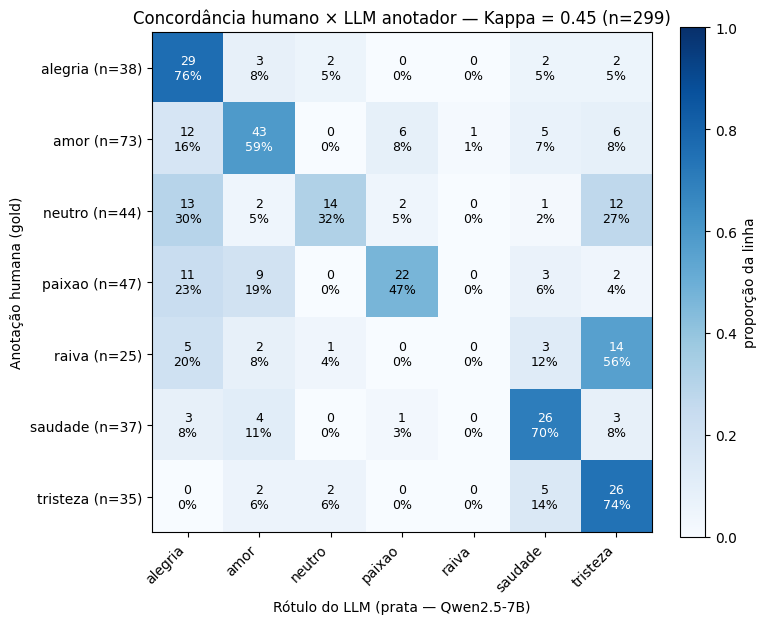

Salva em /kaggle/working/ (.png 300dpi e .pdf vetorial)


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score

# ---------- dados (ajuste os caminhos) ----------
gold  = pd.read_csv("/kaggle/input/datasets/sarahreginadev/manual-gold/gold_300_v1.csv")
prata = pd.read_csv("/kaggle/input/datasets/sarahreginadev/prata-oficial-emocoes/prata_completa_v1.csv")
m = gold.merge(prata, on="id")

CLASSES = ['alegria','amor','neutro','paixao','raiva','saudade','tristeza']
cm = pd.crosstab(m['emocao'], m['emocao_prata']).reindex(
        index=CLASSES, columns=CLASSES, fill_value=0)
cm_pct = cm.div(cm.sum(axis=1), axis=0)   # normalizada por linha (gold)
kappa = cohen_kappa_score(m['emocao'], m['emocao_prata'])

# ---------- figura ----------
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm_pct.values, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(7), CLASSES, rotation=45, ha='right')
ax.set_yticks(range(7), [f"{c} (n={cm.sum(axis=1)[c]})" for c in CLASSES])
ax.set_xlabel("Rótulo do LLM (prata — Qwen2.5-7B)")
ax.set_ylabel("Anotação humana (gold)")
ax.set_title(f"Concordância humano × LLM anotador — Kappa = {kappa:.2f} (n={len(m)})")

# contagem + % em cada célula, com contraste automático
for i in range(7):
    for j in range(7):
        v, p = cm.values[i, j], cm_pct.values[i, j]
        cor = "white" if p > 0.5 else "black"
        ax.text(j, i, f"{v}\n{p:.0%}", ha="center", va="center",
                fontsize=9, color=cor)

fig.colorbar(im, ax=ax, label="proporção da linha", fraction=0.046)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_matriz_gold_vs_prata.png", dpi=300,
            bbox_inches="tight")
plt.savefig("/kaggle/working/fig_matriz_gold_vs_prata.pdf",
            bbox_inches="tight")   # versão vetorial pro LaTeX
plt.show()
print("Salva em /kaggle/working/ (.png 300dpi e .pdf vetorial)")

## 15. Análises complementares — visão geral

Complementa o notebook principal com: **(1)** avaliação multinível — as 7 classes agrupadas por valência (positiva: alegria/amor/paixao · neutra: neutro · negativa: tristeza/raiva/saudade); **(2)** decomposição dos erros (intra vs. inter-família); **(3)** ensemble dos encoders; **(4)** análise qualitativa de erros com categorização (incl. a categoria *'modelo aprendeu rótulo prata'* — diagnóstico de ruído herdado na destilação).

**Racional metodológico:** a avaliação em 3 classes não substitui a de 7 — ela *explica onde mora a dificuldade*: se o desempenho sobe muito ao agrupar, os erros estão nas distinções finas dentro da mesma polaridade, exatamente as fronteiras que desafiam anotadores humanos.

## 16. Avaliação em 3 classes (todos os métodos)

In [27]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, cohen_kappa_score

# ---------- mesmos arquivos da avaliação final ----------
GOLD_CSV   = "/kaggle/input/datasets/sarahreginadev/manual-gold/gold_300_v1.csv"
PRATA_CSV  = "/kaggle/input/datasets/sarahreginadev/prata-oficial-emocoes/prata_completa_v1.csv"
PRED_BERT  = "/kaggle/input/datasets/sarahreginadev/berts/pred_gold_bertimbau.csv"
PRED_DIST  = "/kaggle/input/datasets/sarahreginadev/berts/pred_gold_distilbert.csv"
PRED_NRC   = "/kaggle/input/datasets/sarahreginadev/nrc-gold/pred_gold_nrc.csv"

MACRO = {'alegria':'positiva', 'amor':'positiva', 'paixao':'positiva',
         'neutro':'neutra',
         'tristeza':'negativa', 'raiva':'negativa', 'saudade':'negativa'}

gold = pd.read_csv(GOLD_CSV)[['id','emocao']]
m = (gold
     .merge(pd.read_csv(PRATA_CSV)[['id','emocao_prata']], on='id', how='left')
     .merge(pd.read_csv(PRED_BERT), on='id', how='left')
     .merge(pd.read_csv(PRED_DIST), on='id', how='left')
     .merge(pd.read_csv(PRED_NRC),  on='id', how='left'))

METODOS = {"NRC (léxico)": "pred_nrc", "Qwen2.5-7B (prompt)": "emocao_prata",
           "BERTimbau (ft)": "pred_bertimbau", "DistilBERT (ft)": "pred_distilbert"}

print(f"{'método':<22} {'macroF1_7cls':>12} {'macroF1_3cls':>12} {'acc_3cls':>9} {'kappa_3cls':>10}")
for nome, col in METODOS.items():
    sub = m.dropna(subset=[col])
    y7, p7 = sub['emocao'], sub[col]
    y3, p3 = y7.map(MACRO), p7.map(MACRO)
    print(f"{nome:<22} {f1_score(y7,p7,average='macro',zero_division=0):>12.3f} "
          f"{f1_score(y3,p3,average='macro',zero_division=0):>12.3f} "
          f"{accuracy_score(y3,p3):>9.3f} {cohen_kappa_score(y3,p3):>10.3f}")

# F1 por macro-classe do melhor método (bônus pra discussão)
sub = m.dropna(subset=['emocao_prata'])
print("\nQwen por macro-classe:")
for cls, f1 in zip(['negativa','neutra','positiva'],
                   f1_score(sub['emocao'].map(MACRO), sub['emocao_prata'].map(MACRO),
                            average=None, labels=['negativa','neutra','positiva'])):
    print(f"  {cls}: {f1:.3f}")

método                 macroF1_7cls macroF1_3cls  acc_3cls kappa_3cls
NRC (léxico)                  0.109        0.368     0.457      0.149
Qwen2.5-7B (prompt)           0.473        0.670     0.756      0.573
BERTimbau (ft)                0.391        0.537     0.690      0.441
DistilBERT (ft)               0.359        0.529     0.657      0.379

Qwen por macro-classe:
  negativa: 0.740
  neutra: 0.444
  positiva: 0.826


## 17. Decomposição dos erros: intra vs. inter-família
Que fração dos erros finos 'perdoaria' no agrupamento? Quanto maior a fração intra-família, mais os erros são de *nuance*, não de *polaridade*.

In [28]:
MACRO = {'alegria':'positiva','amor':'positiva','paixao':'positiva','neutro':'neutra',
         'tristeza':'negativa','raiva':'negativa','saudade':'negativa'}

print(f"{'método':<24} {'erros_7cls':>10} {'intra-família':>14} {'%intra':>7}")
for nome, col in METODOS.items():
    sub = m.dropna(subset=[col])
    err = sub[sub['emocao'] != sub[col]]
    intra = (err['emocao'].map(MACRO) == err[col].map(MACRO)).sum()
    print(f"{nome:<24} {len(err):>10} {intra:>14} {100*intra/max(len(err),1):>6.1f}%")

método                   erros_7cls  intra-família  %intra
NRC (léxico)                    251             88   35.1%
Qwen2.5-7B (prompt)             139             66   47.5%
BERTimbau (ft)                  164             71   43.3%
DistilBERT (ft)                 171             68   39.8%


## 18. Matriz de confusão 3×3 — melhor método (Qwen)

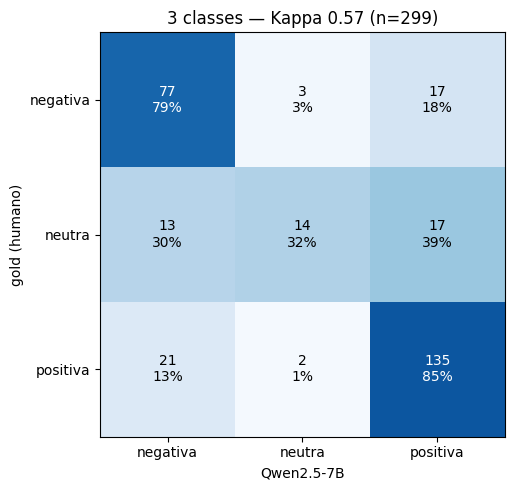

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score
M3 = ['negativa','neutra','positiva']
sub = m.dropna(subset=['emocao_prata'])
y3, p3 = sub['emocao'].map(MACRO), sub['emocao_prata'].map(MACRO)
cm = confusion_matrix(y3, p3, labels=M3)
cm_pct = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(5.5,5))
ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(3), M3); ax.set_yticks(range(3), M3)
ax.set_xlabel('Qwen2.5-7B'); ax.set_ylabel('gold (humano)')
ax.set_title(f'3 classes — Kappa {cohen_kappa_score(y3,p3):.2f} (n={len(sub)})')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{cm[i,j]}\n{cm_pct[i,j]:.0%}', ha='center', va='center',
                color='white' if cm_pct[i,j]>0.5 else 'black')
plt.tight_layout()
plt.savefig('/kaggle/working/fig_matriz_3classes_qwen.png', dpi=300, bbox_inches='tight')
plt.savefig('/kaggle/working/fig_matriz_3classes_qwen.pdf', bbox_inches='tight')
plt.show()

## 19. Ensemble dos encoders (opcional)
Combinação BERTimbau+DistilBERT (média de probabilidades). Resultado: macro-F1 **0,427** (7 cls) — acima de cada encoder isolado, abaixo do professor. A geração exige os checkpoints de treino; protegida por flag (a `pred_ensemble` já salva pode ser lida direto).

In [30]:
EXECUTAR_ENSEMBLE = False  # mude para True SOMENTE para reexecutar esta etapa

if not EXECUTAR_ENSEMBLE:
    print('Geração do ensemble desativada — usar pred_ensemble já salva.')
else:
    import pandas as pd
    import numpy as np
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    from torch.utils.data import Dataset
    import os

    # ---------- CONFIG ----------
    CLASSES = sorted(['alegria','amor','paixao','neutro','tristeza','raiva','saudade'])
    id2label = dict(enumerate(CLASSES))
    label2id = {v: k for k, v in id2label.items()}

    # Caminhos dos checkpoints (use os que você tem)
    BERT_PATH = "/kaggle/working/bertimbau/checkpoint-340"
    DISTIL_PATH = "/kaggle/working/distilbert/checkpoint-408"

    # Carregar tokenizers do modelo original (não dos checkpoints)
    tok_bert = AutoTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")
    tok_distil = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")

    # Carregar modelos dos checkpoints
    model_bert = AutoModelForSequenceClassification.from_pretrained(BERT_PATH)
    model_distil = AutoModelForSequenceClassification.from_pretrained(DISTIL_PATH)

    # Colocar em modo de avaliação
    model_bert.eval()
    model_distil.eval()

    # ---------- DADOS GOLD ----------
    GOLD_CSV = "/kaggle/input/datasets/sarahreginadev/manual-gold/gold_300_v1.csv"
    CORPUS_CSV = "/kaggle/input/datasets/sarahreginadev/corpus-limpo/corpus_oficial_1496.csv"

    gold = pd.read_csv(GOLD_CSV)
    corpus = pd.read_csv(CORPUS_CSV)
    gold = gold.merge(corpus[['id', 'letra']], on='id')

    # Dataset para o gold
    class DS(Dataset):
        def __init__(self, textos, labels, tok):
            self.enc = tok(list(textos), truncation=True, max_length=512,
                           padding='max_length')
            self.labels = list(labels)
        def __len__(self): return len(self.labels)
        def __getitem__(self, i):
            item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
            item['labels'] = torch.tensor(self.labels[i])
            return item

    ds_gold_bert = DS(gold['letra'], [0]*len(gold), tok_bert)
    ds_gold_distil = DS(gold['letra'], [0]*len(gold), tok_distil)

    # Função para obter logits
    def get_logits(model, dataset, batch_size=32):
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)
        logits_list = []
        with torch.no_grad():
            for batch in dataloader:
                inputs = {k: v.to(model.device) for k, v in batch.items() if k != 'labels'}
                outputs = model(**inputs)
                logits_list.append(outputs.logits.cpu())
        return torch.cat(logits_list, dim=0)

    # Colocar modelos na GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_bert.to(device)
    model_distil.to(device)

    # Obter logits
    print("Obtendo logits do BERTimbau...")
    logits_bert = get_logits(model_bert, ds_gold_bert)
    print("Obtendo logits do DistilBERT...")
    logits_distil = get_logits(model_distil, ds_gold_distil)

    # Média dos logits
    logits_ensemble = (logits_bert + logits_distil) / 2
    preds = logits_ensemble.argmax(dim=-1).numpy()

    # Salvar predições
    gold_out = gold[['id']].copy()
    gold_out['pred_ensemble'] = [id2label[p] for p in preds]
    gold_out.to_csv("/kaggle/working/pred_gold_ensemble.csv", index=False)

    print("✅ Predições do ensemble salvas em pred_gold_ensemble.csv")
    print("\nDistribuição das predições:")
    print(gold_out['pred_ensemble'].value_counts())

Geração do ensemble desativada — usar pred_ensemble já salva.


=== TABELA PRINCIPAL (vs gold) ===
                método   n  macro_F1  acurácia  kappa
   Qwen2.5-7B (prompt) 299     0.473     0.535  0.450
Ensemble (BERT+Distil) 300     0.427     0.490  0.397
        BERTimbau (ft) 300     0.427     0.490  0.397
       DistilBERT (ft) 300     0.310     0.383  0.263
          NRC (léxico) 300     0.109     0.163  0.052

=== F1 POR CLASSE ===
          n_gold  NRC (léxico)  Qwen2.5-7B (prompt)  BERTimbau (ft)  DistilBERT (ft)  Ensemble (BERT+Distil)
alegria       38         0.286                0.523           0.544            0.391                   0.544
amor          73         0.000                0.623           0.589            0.521                   0.589
paixao        47         0.000                0.564           0.571            0.301                   0.571
neutro        44         0.079                0.444           0.083            0.083                   0.083
tristeza      35         0.298                0.520           0.505      

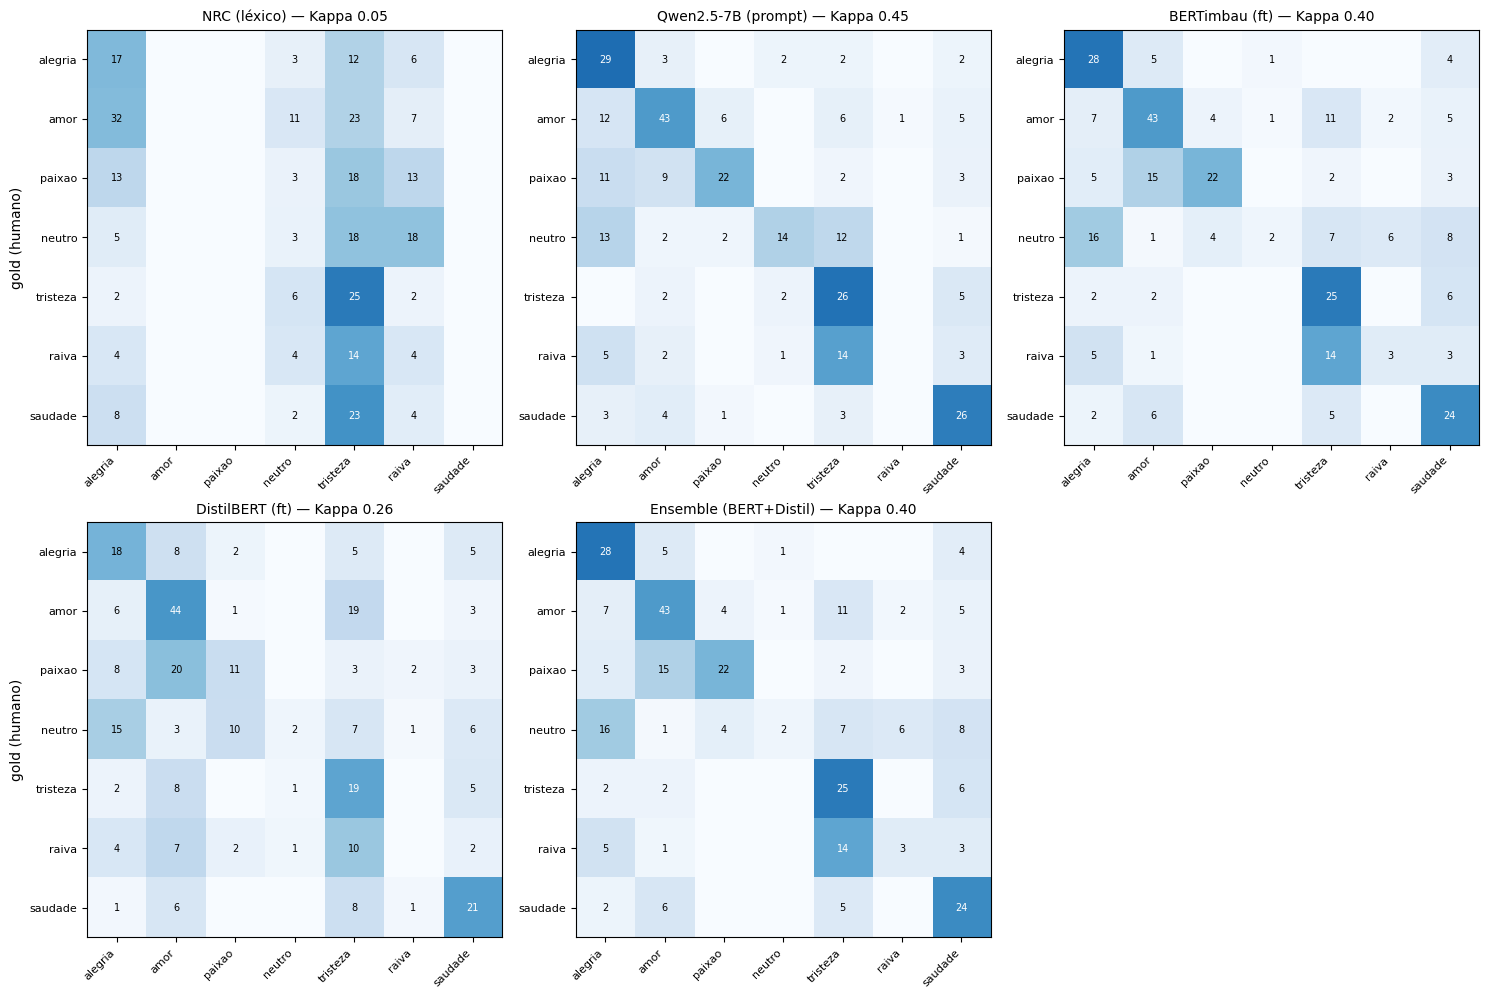


📁 Arquivos gerados:
  - tabela_principal_com_ensemble.csv
  - f1_por_classe_com_ensemble.csv
  - fig_matrizes_com_ensemble.png/pdf


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, cohen_kappa_score, confusion_matrix

# ---------- CONFIG (caminhos dos arquivos) ----------
GOLD_CSV    = "/kaggle/input/datasets/sarahreginadev/manual-gold/gold_300_v1.csv"
PRATA_CSV   = "/kaggle/input/datasets/sarahreginadev/prata-oficial-emocoes/prata_completa_v1.csv"
PRED_BERT   = "/kaggle/working/pred_gold_bertimbau.csv"
PRED_DIST   = "/kaggle/working/pred_gold_distilbert.csv"
PRED_NRC    = "/kaggle/working/pred_gold_nrc.csv"  # se não tiver, comente
PRED_ENSEMBLE = "/kaggle/working/pred_gold_ensemble.csv"

CLASSES = ['alegria','amor','paixao','neutro','tristeza','raiva','saudade']

# ---------- MONTAGEM DOS DADOS ----------
gold = pd.read_csv(GOLD_CSV)[['id','emocao']]

m = (gold
     .merge(pd.read_csv(PRATA_CSV)[['id','emocao_prata']], on='id', how='left')
     .merge(pd.read_csv(PRED_BERT), on='id', how='left')
     .merge(pd.read_csv(PRED_DIST), on='id', how='left')
     .merge(pd.read_csv(PRED_NRC),  on='id', how='left')
     .merge(pd.read_csv(PRED_ENSEMBLE), on='id', how='left')  # <-- ENSEMBLE ADICIONADO
)

METODOS = {
    "NRC (léxico)": "pred_nrc",
    "Qwen2.5-7B (prompt)": "emocao_prata",
    "BERTimbau (ft)": "pred_bertimbau",
    "DistilBERT (ft)": "pred_distilbert",
    "Ensemble (BERT+Distil)": "pred_ensemble",  # <-- MÉTODO ADICIONADO
}

# ---------- TABELA PRINCIPAL ----------
linhas = []
for nome, col in METODOS.items():
    sub = m.dropna(subset=[col])
    y, p = sub['emocao'], sub[col]
    linhas.append({
        "método": nome,
        "n": len(sub),
        "macro_F1": round(f1_score(y, p, average='macro', labels=CLASSES, zero_division=0), 3),
        "acurácia": round(accuracy_score(y, p), 3),
        "kappa":    round(cohen_kappa_score(y, p), 3),
    })
tab = pd.DataFrame(linhas).sort_values("macro_F1", ascending=False)
print("=== TABELA PRINCIPAL (vs gold) ===")
print(tab.to_string(index=False))
tab.to_csv("/kaggle/working/tabela_principal_com_ensemble.csv", index=False)

# ---------- F1 POR CLASSE ----------
f1c = {}
for nome, col in METODOS.items():
    sub = m.dropna(subset=[col])
    f1c[nome] = f1_score(sub['emocao'], sub[col], average=None,
                         labels=CLASSES, zero_division=0).round(3)
f1_classe = pd.DataFrame(f1c, index=CLASSES)
suporte = gold['emocao'].value_counts().reindex(CLASSES)
f1_classe.insert(0, "n_gold", suporte.values)
print("\n=== F1 POR CLASSE ===")
print(f1_classe.to_string())
f1_classe.to_csv("/kaggle/working/f1_por_classe_com_ensemble.csv")

# ---------- MATRIZES DE CONFUSÃO (figura 2x3 ou 2x2?) ----------
# Vamos fazer uma grade com os 5 métodos
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for ax, (nome, col) in zip(axes, METODOS.items()):
    sub = m.dropna(subset=[col])
    cm = confusion_matrix(sub['emocao'], sub[col], labels=CLASSES)
    cm_pct = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(7), CLASSES, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(7), CLASSES, fontsize=8)
    k = cohen_kappa_score(sub['emocao'], sub[col])
    ax.set_title(f"{nome} — Kappa {k:.2f}", fontsize=10)
    for i in range(7):
        for j in range(7):
            if cm[i, j] > 0:
                ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=7,
                        color="white" if cm_pct[i, j] > 0.5 else "black")
axes[0].set_ylabel("gold (humano)")
axes[3].set_ylabel("gold (humano)")
# Remove o último gráfico vazio (se houver)
if len(METODOS) < 6:
    for k in range(len(METODOS), 6):
        fig.delaxes(axes[k])
plt.tight_layout()
plt.savefig("/kaggle/working/fig_matrizes_com_ensemble.png", dpi=300, bbox_inches="tight")
plt.savefig("/kaggle/working/fig_matrizes_com_ensemble.pdf", bbox_inches="tight")
plt.show()

print("\n📁 Arquivos gerados:")
print("  - tabela_principal_com_ensemble.csv")
print("  - f1_por_classe_com_ensemble.csv")
print("  - fig_matrizes_com_ensemble.png/pdf")

## 20. Análise qualitativa de erros
Monta a base unificada, categoriza cada erro (destaque: **'modelo aprendeu rótulo prata'** = o encoder previu exatamente o rótulo ruidoso do professor), lista os pares mais confundidos e exporta amostras (CSV + relatório HTML) para citação no artigo.

In [32]:
import pandas as pd
import numpy as np

# ---------- CONFIG ----------
GOLD_CSV    = "/kaggle/input/datasets/sarahreginadev/manual-gold/gold_300_v1.csv"
CORPUS_CSV  = "/kaggle/input/datasets/sarahreginadev/corpus-limpo/corpus_oficial_1496.csv"
PRATA_CSV   = "/kaggle/input/datasets/sarahreginadev/prata-oficial-emocoes/prata_completa_v1.csv"

# Predições que você gerou
PRED_BERT   = "/kaggle/working/pred_gold_bertimbau.csv"
PRED_DIST   = "/kaggle/working/pred_gold_distilbert.csv"
PRED_ENSEMBLE = "/kaggle/working/pred_gold_ensemble.csv"

CLASSES = ['alegria','amor','paixao','neutro','tristeza','raiva','saudade']

# Carregar base
gold = pd.read_csv(GOLD_CSV)[['id','emocao']]
corpus = pd.read_csv(CORPUS_CSV)[['id', 'titulo', 'artista', 'letra']]
prata = pd.read_csv(PRATA_CSV)[['id', 'emocao_prata']]

# Merge tudo
df = gold.merge(corpus, on='id', how='left')
df = df.merge(prata, on='id', how='left')
df = df.merge(pd.read_csv(PRED_BERT)[['id', 'pred_bertimbau']], on='id', how='left')
df = df.merge(pd.read_csv(PRED_DIST)[['id', 'pred_distilbert']], on='id', how='left')
df = df.merge(pd.read_csv(PRED_ENSEMBLE)[['id', 'pred_ensemble']], on='id', how='left')

# Colunas de predição do Qwen (vem do prata)
df['pred_qwen'] = df['emocao_prata']

print(f"Total de músicas: {len(df)}")
print(df.head(2))

Total de músicas: 300
     id emocao                                             titulo  \
0  1109   amor  Além De Tudo / Retalhos De Cetim / Charlie Bro...   
1   562   amor                          Me Caiu Tão Bem - Ao Vivo   

           artista                                              letra  \
0  Grupo Revelação  Você ficou sem jeito e encabulada Ficou parada...   
1      Murilo Huff  Sou um cara normal Que usa um boné pra trás e ...   

  emocao_prata pred_bertimbau pred_distilbert pred_ensemble pred_qwen  
0      alegria           amor        tristeza          amor   alegria  
1         amor       tristeza        tristeza      tristeza      amor  


In [33]:
# Filtra erros do Ensemble (seu melhor modelo de encoder)
df_erros_ensemble = df[df['emocao'] != df['pred_ensemble']].copy()
# Filtra erros do Qwen
df_erros_qwen = df[df['emocao'] != df['pred_qwen']].copy()

print(f"Erros do Ensemble: {len(df_erros_ensemble)}")
print(f"Erros do Qwen: {len(df_erros_qwen)}")

Erros do Ensemble: 153
Erros do Qwen: 140


In [34]:
def categorizar_erro(row):
    gold = row['emocao']
    pred = row['pred_ensemble']  # Pode mudar para 'pred_qwen' se quiser analisar o LLM
    
    # 1. Ruído do rótulo prata? (O modelo previu exatamente o que está no prata?)
    if pd.notna(row['emocao_prata']) and pred == row['emocao_prata'] and pred != gold:
        return "🚨 Modelo aprendeu rótulo prata (ruído)"
    
    # 2. Confusão dentro da mesma polaridade (positiva, negativa ou neutra)
    positivas = {'alegria', 'amor', 'paixao'}
    negativas = {'tristeza', 'raiva', 'saudade'}
    neutras = {'neutro'}
    
    if gold in positivas and pred in positivas:
        return "🔀 Ambiguidade dentro do positivo (ex: amor vs paixao)"
    if gold in negativas and pred in negativas:
        return "🔀 Ambiguidade dentro do negativo (ex: tristeza vs saudade)"
    
    # 3. Confusão entre polaridades opostas
    if (gold in positivas and pred in negativas) or (gold in negativas and pred in positivas):
        return "⚠️ Erro de polaridade (confundiu positivo com negativo)"
    
    # 4. Neutro confundido com emocional
    if gold == 'neutro' and pred in positivas.union(negativas):
        return "🤔 Neutro classificado como emocional"
    if pred == 'neutro' and gold in positivas.union(negativas):
        return "😐 Emocional classificado como neutro"
    
    return "❓ Outro tipo de erro"

# Aplica a categorização para o Ensemble
df_erros_ensemble['tipo_erro'] = df_erros_ensemble.apply(categorizar_erro, axis=1)
df_erros_qwen['tipo_erro'] = df_erros_qwen.apply(lambda r: categorizar_erro(r), axis=1)

print("Distribuição dos tipos de erro no Ensemble:")
print(df_erros_ensemble['tipo_erro'].value_counts())

Distribuição dos tipos de erro no Ensemble:
tipo_erro
🚨 Modelo aprendeu rótulo prata (ruído)                        80
🤔 Neutro classificado como emocional                          26
⚠️ Erro de polaridade (confundiu positivo com negativo)       20
🔀 Ambiguidade dentro do positivo (ex: amor vs paixao)         15
🔀 Ambiguidade dentro do negativo (ex: tristeza vs saudade)    10
😐 Emocional classificado como neutro                           2
Name: count, dtype: int64


In [35]:
# Função para pegar um trecho da letra (evitar textos muito longos)
def snippet(texto, tamanho=150):
    if isinstance(texto, str):
        return texto[:tamanho] + "..." if len(texto) > tamanho else texto
    return ""

# Seleciona os erros mais representativos
def amostra_erros(df_erros, modelo_nome, n=20):
    # Tenta balancear pelos tipos de erro
    amostra = df_erros.groupby('tipo_erro').apply(lambda x: x.sample(min(len(x), 3), random_state=42)).reset_index(drop=True)
    if len(amostra) > n:
        amostra = amostra.sample(n, random_state=42)
    
    # Formata para exibição
    cols = ['id', 'titulo', 'artista', 'emocao', f'pred_{modelo_nome}', 'emocao_prata', 'tipo_erro']
    display_cols = [c for c in cols if c in amostra.columns]
    
    # Adiciona trecho da letra
    amostra['trecho_letra'] = amostra['letra'].apply(snippet)
    
    return amostra[display_cols + ['trecho_letra']]

# Para o Ensemble
print("\n" + "="*80)
print("🔍 AMOSTRA DE ERROS DO ENSEMBLE")
print("="*80)
amostra_ensemble = amostra_erros(df_erros_ensemble, 'ensemble', n=15)
display(amostra_ensemble)

# Para o Qwen
print("\n" + "="*80)
print("🔍 AMOSTRA DE ERROS DO QWEN (PRATA)")
print("="*80)
amostra_qwen = amostra_erros(df_erros_qwen, 'qwen', n=15)
display(amostra_qwen)


🔍 AMOSTRA DE ERROS DO ENSEMBLE


/tmp/ipykernel_58/1259861603.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  amostra = df_erros.groupby('tipo_erro').apply(lambda x: x.sample(min(len(x), 3), random_state=42)).reset_index(drop=True)


,id,titulo,artista,emocao,pred_ensemble,emocao_prata,tipo_erro,trecho_letra
0,562,Me Caiu Tão Bem - Ao Vivo,Murilo Huff,amor,tristeza,amor,⚠️ Erro de polaridade (confundiu positivo com ...,Sou um cara normal Que usa um boné pra trás e ...
1,43,Tá Vendo Aquela Lua,Exaltasamba,amor,tristeza,amor,⚠️ Erro de polaridade (confundiu positivo com ...,Te filmando eu tava quieto no meu canto Cabelo...
5,1059,Construção,Chico Buarque,saudade,tristeza,alegria,🔀 Ambiguidade dentro do negativo (ex: tristeza...,Amou daquela vez como se fosse a última Beijou...
15,1159,Bom-Senso,Tim Maia,neutro,saudade,neutro,🤔 Neutro classificado como emocional,Já virei calçada maltratada E na virada quase ...
11,52,Um Beijo,Luan Santana,alegria,amor,amor,🚨 Modelo aprendeu rótulo prata (ruído),Sai cantando do chuveiro Eu sou o cara mais fe...
14,419,Diário de um Detento,Racionais MC's,neutro,raiva,tristeza,🤔 Neutro classificado como emocional,"São Paulo, dia 1º de Outubro de 1992, oito hor..."
8,64,Envolvidão,Rael,amor,paixao,amor,🔀 Ambiguidade dentro do positivo (ex: amor vs ...,"Ela tem cores, curvas, sabores Coisas que sedu..."
13,424,"Era um Garoto, Que Como Eu, Amava os Beatles e...",Engenheiros Do Hawaii,neutro,tristeza,tristeza,🚨 Modelo aprendeu rótulo prata (ruído),Era um garoto que como eu Amava os Beatles e o...
2,1049,Águas De Março,Elis Regina,tristeza,alegria,neutro,⚠️ Erro de polaridade (confundiu positivo com ...,"É pau, é pedra, é o fim do caminho É um resto ..."
9,431,Cachimbo da Paz (feat. Lulu Santos),Gabriel O Pensador,alegria,neutro,tristeza,😐 Emocional classificado como neutro,A criminalidade toma conta da cidade A socieda...



🔍 AMOSTRA DE ERROS DO QWEN (PRATA)


/tmp/ipykernel_58/1259861603.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  amostra = df_erros.groupby('tipo_erro').apply(lambda x: x.sample(min(len(x), 3), random_state=42)).reset_index(drop=True)


,id,titulo,artista,emocao,pred_qwen,emocao_prata,tipo_erro,trecho_letra
0,53,Mentes Tão Bem,Zezé Di Camargo & Luciano,raiva,tristeza,tristeza,⚠️ Erro de polaridade (confundiu positivo com ...,Me promete amor sincero Uma vida inteira Que c...
1,1152,Como 2 E 2 - Ao Vivo / Introdução,Gal Costa,tristeza,neutro,neutro,⚠️ Erro de polaridade (confundiu positivo com ...,Quando você me ouvir chorar Tente não cante nã...
8,1330,Deixa Acontecer,Grupo Revelação,amor,saudade,saudade,🔀 Ambiguidade dentro do positivo (ex: amor vs ...,Deixa acontecer naturalmente Eu não quero ver ...
5,1059,Construção,Chico Buarque,saudade,alegria,alegria,🔀 Ambiguidade dentro do negativo (ex: tristeza...,Amou daquela vez como se fosse a última Beijou...
3,12,Admirável Chip Novo,Pitty,neutro,tristeza,tristeza,❓ Outro tipo de erro,"Pane no sistema, alguém me desconfigurou Aonde..."
13,502,Bum Bum Tam Tam,MC Fioti,paixao,alegria,alegria,🚨 Modelo aprendeu rótulo prata (ruído),É a flauta envolvente que mexe com a mente De ...
16,1417,A Dois Passos Do Paraíso,Blitz,neutro,tristeza,tristeza,🤔 Neutro classificado como emocional,Longe de casa Há mais de uma semana Milhas e m...
15,233,Pedido A Padre Cícero,Ary Lobo,neutro,tristeza,tristeza,🤔 Neutro classificado como emocional,Ó seco tá torrando de novo o meu ceará Ó meu s...
11,441,Por Você - Ao Vivo,Frejat,amor,alegria,alegria,😐 Emocional classificado como neutro,"Por você eu dançaria tango no teto, Eu limpari..."
2,465,"Vida Loka, Pt. 1",Racionais MC's,raiva,neutro,neutro,⚠️ Erro de polaridade (confundiu positivo com ...,"Vagabunda, queria a taca do malucão, usou meu ..."



📊 TOP 5 PARES MAIS CONFUNDIDOS PELO ENSEMBLE:
  Gold: neutro → Pred: alegria  |  16 vezes
  Gold: paixao → Pred: amor  |  15 vezes
  Gold: raiva → Pred: tristeza  |  14 vezes
  Gold: amor → Pred: tristeza  |  11 vezes
  Gold: neutro → Pred: saudade  |  8 vezes


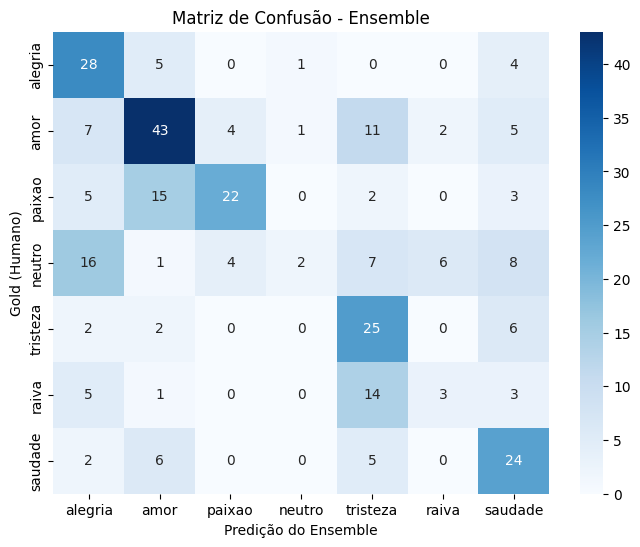

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de confusão para o Ensemble
cm = confusion_matrix(df['emocao'], df['pred_ensemble'], labels=CLASSES)
cm_df = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)

print("\n📊 TOP 5 PARES MAIS CONFUNDIDOS PELO ENSEMBLE:")
# Pega os maiores valores fora da diagonal principal
confusos = []
for i, gold in enumerate(CLASSES):
    for j, pred in enumerate(CLASSES):
        if i != j and cm[i, j] > 0:
            confusos.append((gold, pred, cm[i, j]))

confusos.sort(key=lambda x: x[2], reverse=True)
for gold, pred, count in confusos[:5]:
    print(f"  Gold: {gold} → Pred: {pred}  |  {count} vezes")

# Plota a matriz com foco nos erros
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Matriz de Confusão - Ensemble')
plt.ylabel('Gold (Humano)')
plt.xlabel('Predição do Ensemble')
plt.show()

In [37]:
confusos = []
for i, gold in enumerate(CLASSES):
    for j, pred in enumerate(CLASSES):
        if i != j and cm[i, j] > 0:
            confusos.append((gold, pred, cm[i, j]))

confusos.sort(key=lambda x: x[2], reverse=True)
print("\n📊 TOP 5 PARES MAIS CONFUNDIDOS PELO ENSEMBLE:")
for gold, pred, count in confusos[:5]:
    print(f"  Gold: {gold} → Pred: {pred}  |  {count} vezes")


📊 TOP 5 PARES MAIS CONFUNDIDOS PELO ENSEMBLE:
  Gold: neutro → Pred: alegria  |  16 vezes
  Gold: paixao → Pred: amor  |  15 vezes
  Gold: raiva → Pred: tristeza  |  14 vezes
  Gold: amor → Pred: tristeza  |  11 vezes
  Gold: neutro → Pred: saudade  |  8 vezes


In [38]:
# Exporta CSVs
if not amostra_ensemble.empty:
    amostra_ensemble.to_csv("/kaggle/working/analise_erros_ensemble.csv", index=False)
if not amostra_qwen.empty:
    amostra_qwen.to_csv("/kaggle/working/analise_erros_qwen.csv", index=False)

# Gera o relatório HTML
try:
    with open("/kaggle/working/relatorio_erros.html", "w", encoding='utf-8') as f:
        f.write("<html><head><meta charset='UTF-8'><title>Análise de Erros</title></head><body>")
        f.write("<h1>Análise Qualitativa de Erros</h1>")
        
        # Distribuição dos erros (Ensemble)
        if not df_erros_ensemble.empty and 'tipo_erro' in df_erros_ensemble.columns:
            f.write("<h2>1. Distribuição dos Erros (Ensemble)</h2>")
            # CORREÇÃO AQUI: .to_frame() antes de .to_html()
            f.write(df_erros_ensemble['tipo_erro'].value_counts().to_frame().to_html())
        
        # Amostra Ensemble
        if not amostra_ensemble.empty:
            f.write("<h2>2. Amostra de Erros (Ensemble)</h2>")
            f.write(amostra_ensemble.to_html())
        else:
            f.write("<p>Nenhum erro encontrado para o Ensemble.</p>")
        
        # Amostra Qwen
        if not amostra_qwen.empty:
            f.write("<h2>3. Amostra de Erros (Qwen)</h2>")
            f.write(amostra_qwen.to_html())
        else:
            f.write("<p>Nenhum erro encontrado para o Qwen.</p>")
            
        f.write("</body></html>")
    print("✅ Relatório salvo em /kaggle/working/relatorio_erros.html")
except Exception as e:
    print(f"❌ Erro ao gerar relatório: {e}")

✅ Relatório salvo em /kaggle/working/relatorio_erros.html


In [39]:
print("\n" + "="*80)
print("🔍 AMOSTRA DE ERROS DO ENSEMBLE")
print("="*80)
display(amostra_ensemble)

print("\n" + "="*80)
print("🔍 AMOSTRA DE ERROS DO QWEN")
print("="*80)
display(amostra_qwen)


🔍 AMOSTRA DE ERROS DO ENSEMBLE


,id,titulo,artista,emocao,pred_ensemble,emocao_prata,tipo_erro,trecho_letra
0,562,Me Caiu Tão Bem - Ao Vivo,Murilo Huff,amor,tristeza,amor,⚠️ Erro de polaridade (confundiu positivo com ...,Sou um cara normal Que usa um boné pra trás e ...
1,43,Tá Vendo Aquela Lua,Exaltasamba,amor,tristeza,amor,⚠️ Erro de polaridade (confundiu positivo com ...,Te filmando eu tava quieto no meu canto Cabelo...
5,1059,Construção,Chico Buarque,saudade,tristeza,alegria,🔀 Ambiguidade dentro do negativo (ex: tristeza...,Amou daquela vez como se fosse a última Beijou...
15,1159,Bom-Senso,Tim Maia,neutro,saudade,neutro,🤔 Neutro classificado como emocional,Já virei calçada maltratada E na virada quase ...
11,52,Um Beijo,Luan Santana,alegria,amor,amor,🚨 Modelo aprendeu rótulo prata (ruído),Sai cantando do chuveiro Eu sou o cara mais fe...
14,419,Diário de um Detento,Racionais MC's,neutro,raiva,tristeza,🤔 Neutro classificado como emocional,"São Paulo, dia 1º de Outubro de 1992, oito hor..."
8,64,Envolvidão,Rael,amor,paixao,amor,🔀 Ambiguidade dentro do positivo (ex: amor vs ...,"Ela tem cores, curvas, sabores Coisas que sedu..."
13,424,"Era um Garoto, Que Como Eu, Amava os Beatles e...",Engenheiros Do Hawaii,neutro,tristeza,tristeza,🚨 Modelo aprendeu rótulo prata (ruído),Era um garoto que como eu Amava os Beatles e o...
2,1049,Águas De Março,Elis Regina,tristeza,alegria,neutro,⚠️ Erro de polaridade (confundiu positivo com ...,"É pau, é pedra, é o fim do caminho É um resto ..."
9,431,Cachimbo da Paz (feat. Lulu Santos),Gabriel O Pensador,alegria,neutro,tristeza,😐 Emocional classificado como neutro,A criminalidade toma conta da cidade A socieda...



🔍 AMOSTRA DE ERROS DO QWEN


,id,titulo,artista,emocao,pred_qwen,emocao_prata,tipo_erro,trecho_letra
0,53,Mentes Tão Bem,Zezé Di Camargo & Luciano,raiva,tristeza,tristeza,⚠️ Erro de polaridade (confundiu positivo com ...,Me promete amor sincero Uma vida inteira Que c...
1,1152,Como 2 E 2 - Ao Vivo / Introdução,Gal Costa,tristeza,neutro,neutro,⚠️ Erro de polaridade (confundiu positivo com ...,Quando você me ouvir chorar Tente não cante nã...
8,1330,Deixa Acontecer,Grupo Revelação,amor,saudade,saudade,🔀 Ambiguidade dentro do positivo (ex: amor vs ...,Deixa acontecer naturalmente Eu não quero ver ...
5,1059,Construção,Chico Buarque,saudade,alegria,alegria,🔀 Ambiguidade dentro do negativo (ex: tristeza...,Amou daquela vez como se fosse a última Beijou...
3,12,Admirável Chip Novo,Pitty,neutro,tristeza,tristeza,❓ Outro tipo de erro,"Pane no sistema, alguém me desconfigurou Aonde..."
13,502,Bum Bum Tam Tam,MC Fioti,paixao,alegria,alegria,🚨 Modelo aprendeu rótulo prata (ruído),É a flauta envolvente que mexe com a mente De ...
16,1417,A Dois Passos Do Paraíso,Blitz,neutro,tristeza,tristeza,🤔 Neutro classificado como emocional,Longe de casa Há mais de uma semana Milhas e m...
15,233,Pedido A Padre Cícero,Ary Lobo,neutro,tristeza,tristeza,🤔 Neutro classificado como emocional,Ó seco tá torrando de novo o meu ceará Ó meu s...
11,441,Por Você - Ao Vivo,Frejat,amor,alegria,alegria,😐 Emocional classificado como neutro,"Por você eu dançaria tango no teto, Eu limpari..."
2,465,"Vida Loka, Pt. 1",Racionais MC's,raiva,neutro,neutro,⚠️ Erro de polaridade (confundiu positivo com ...,"Vagabunda, queria a taca do malucão, usou meu ..."


## 21. Análises Complementares — Métricas Detalhadas e Recortes por Subgrupo).

In [40]:
# =====================================================
# ANÁLISES COMPLEMENTARES - VERSÃO FINAL
# (Execute após a Seção 20)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report
from collections import Counter

# Configuração de estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Garantir que o dataframe 'm' (da Seção 13) esteja disponível
# Se não estiver, recarregue os dados
try:
    m
except NameError:
    GOLD_CSV   = "/kaggle/input/datasets/sarahreginadev/manual-gold/gold_300_v1.csv"
    PRATA_CSV  = "/kaggle/input/datasets/sarahreginadev/prata-oficial-emocoes/prata_completa_v1.csv"
    PRED_BERT  = "/kaggle/input/datasets/sarahreginadev/berts/pred_gold_bertimbau.csv"
    PRED_DIST  = "/kaggle/input/datasets/sarahreginadev/berts/pred_gold_distilbert.csv"
    PRED_NRC   = "/kaggle/input/datasets/sarahreginadev/nrc-gold/pred_gold_nrc.csv"
    PRED_ENSEMBLE = "/kaggle/working/pred_gold_ensemble.csv"  # se existir
    
    gold = pd.read_csv(GOLD_CSV)[['id','emocao']]
    m = (gold
         .merge(pd.read_csv(PRATA_CSV)[['id','emocao_prata']], on='id', how='left')
         .merge(pd.read_csv(PRED_BERT), on='id', how='left')
         .merge(pd.read_csv(PRED_DIST), on='id', how='left')
         .merge(pd.read_csv(PRED_NRC),  on='id', how='left')
         .merge(pd.read_csv(PRED_ENSEMBLE), on='id', how='left')
    )

CLASSES = ['alegria','amor','paixao','neutro','tristeza','raiva','saudade']
METODOS = {
    "NRC (léxico)": "pred_nrc",
    "Qwen2.5-7B (prompt)": "emocao_prata",
    "BERTimbau (ft)": "pred_bertimbau",
    "DistilBERT (ft)": "pred_distilbert",
    "Ensemble (BERT+Distil)": "pred_ensemble"
}
# Remover métodos que não existem
METODOS = {k:v for k,v in METODOS.items() if v in m.columns}

print("✅ Dados carregados. Métodos disponíveis:", list(METODOS.keys()))

✅ Dados carregados. Métodos disponíveis: ['NRC (léxico)', 'Qwen2.5-7B (prompt)', 'BERTimbau (ft)', 'DistilBERT (ft)', 'Ensemble (BERT+Distil)']


In [41]:
# =====================================================
# ANÁLISES COMPLEMENTARES - VERSÃO FINAL CORRIGIDA
# (Execute após a Seção 20)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report
from collections import Counter

# Configuração de estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# ---------- RECARREGAR DADOS (para evitar erros de variáveis sobrescritas) ----------
print("Carregando dados...")

GOLD_CSV   = "/kaggle/input/datasets/sarahreginadev/manual-gold/gold_300_v1.csv"
PRATA_CSV  = "/kaggle/input/datasets/sarahreginadev/prata-oficial-emocoes/prata_completa_v1.csv"
PRED_BERT  = "/kaggle/input/datasets/sarahreginadev/berts/pred_gold_bertimbau.csv"
PRED_DIST  = "/kaggle/input/datasets/sarahreginadev/berts/pred_gold_distilbert.csv"
PRED_NRC   = "/kaggle/input/datasets/sarahreginadev/nrc-gold/pred_gold_nrc.csv"
PRED_ENSEMBLE = "/kaggle/working/pred_gold_ensemble.csv"  # pode não existir
CORPUS_CSV = "/kaggle/input/datasets/sarahreginadev/corpus-limpo/corpus_oficial_1496.csv"

# Carregar gold
gold = pd.read_csv(GOLD_CSV)[['id','emocao']]

# Carregar predições
prata = pd.read_csv(PRATA_CSV)[['id','emocao_prata']]
bert = pd.read_csv(PRED_BERT)[['id','pred_bertimbau']]
dist = pd.read_csv(PRED_DIST)[['id','pred_distilbert']]
nrc = pd.read_csv(PRED_NRC)[['id','pred_nrc']]

# Merge tudo
m = gold.merge(prata, on='id', how='left')
m = m.merge(bert, on='id', how='left')
m = m.merge(dist, on='id', how='left')
m = m.merge(nrc, on='id', how='left')

# Se ensemble existir, adicionar
try:
    ensemble = pd.read_csv(PRED_ENSEMBLE)[['id','pred_ensemble']]
    m = m.merge(ensemble, on='id', how='left')
    print("✅ Ensemble carregado.")
except FileNotFoundError:
    print("⚠️ Arquivo de ensemble não encontrado. Continuando sem ele.")

CLASSES = ['alegria','amor','paixao','neutro','tristeza','raiva','saudade']
METODOS = {
    "NRC (léxico)": "pred_nrc",
    "Qwen2.5-7B (prompt)": "emocao_prata",
    "BERTimbau (ft)": "pred_bertimbau",
    "DistilBERT (ft)": "pred_distilbert",
}
if 'pred_ensemble' in m.columns:
    METODOS["Ensemble (BERT+Distil)"] = "pred_ensemble"

print(f"✅ Dados carregados. Métodos disponíveis: {list(METODOS.keys())}")
print(f"Total de amostras no gold: {len(gold)}")
print(f"Total no dataframe m: {len(m)}")

Carregando dados...
✅ Ensemble carregado.
✅ Dados carregados. Métodos disponíveis: ['NRC (léxico)', 'Qwen2.5-7B (prompt)', 'BERTimbau (ft)', 'DistilBERT (ft)', 'Ensemble (BERT+Distil)']
Total de amostras no gold: 300
Total no dataframe m: 300


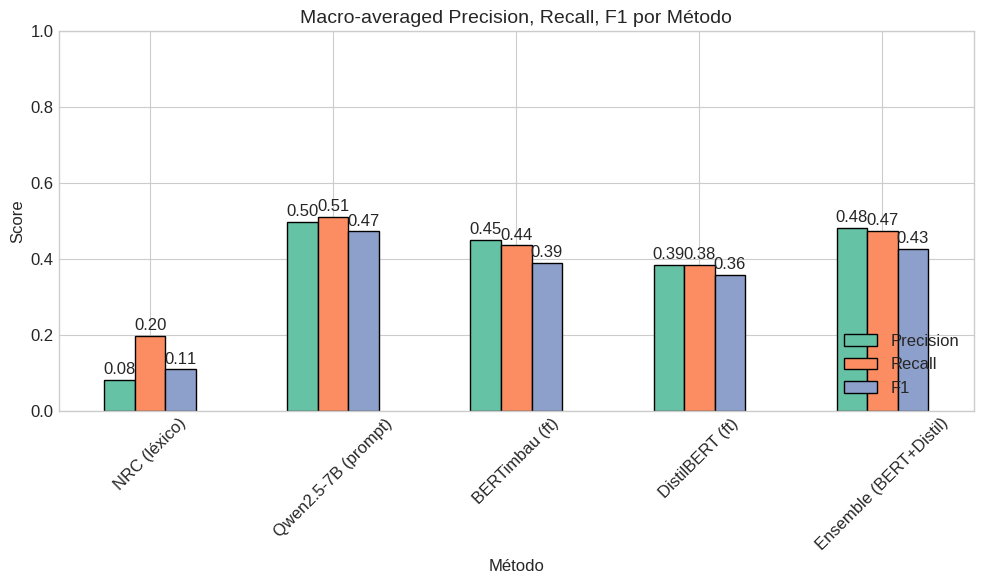

✅ Figuras salvas: fig_macro_precision_recall_f1.png/.pdf


In [42]:
# =====================================================
# 2. Gráfico de barras: Precision, Recall, F1 (macro)
# =====================================================

macro_metrics = {}
for nome, col in METODOS.items():
    sub = m.dropna(subset=[col])
    y_true = sub['emocao']
    y_pred = sub[col]
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, 
                                                       average='macro', 
                                                       zero_division=0)
    macro_metrics[nome] = {'Precision': prec, 'Recall': rec, 'F1': f1}

df_macro = pd.DataFrame(macro_metrics).T
df_macro = df_macro[['Precision', 'Recall', 'F1']]  # reordenar

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
df_macro.plot(kind='bar', ax=ax, rot=45, edgecolor='black')
ax.set_title('Macro-averaged Precision, Recall, F1 por Método', fontsize=14)
ax.set_ylabel('Score')
ax.set_xlabel('Método')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_macro_precision_recall_f1.png', dpi=300, bbox_inches='tight')
plt.savefig('/kaggle/working/fig_macro_precision_recall_f1.pdf', bbox_inches='tight')
plt.show()
print("✅ Figuras salvas: fig_macro_precision_recall_f1.png/.pdf")

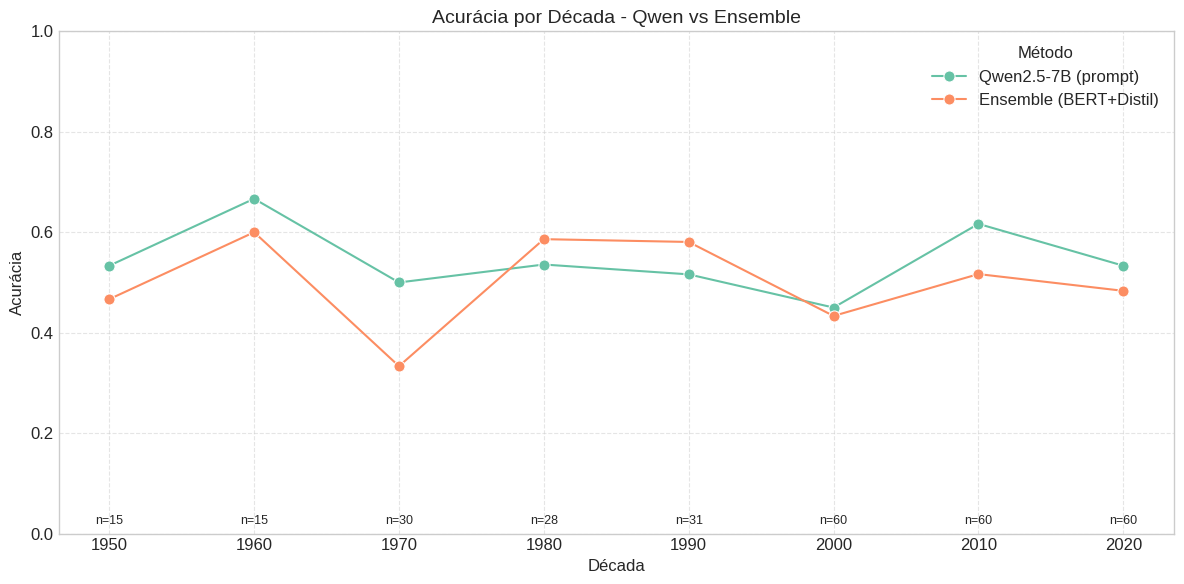

✅ Figuras salvas: fig_desempenho_por_decada.png/.pdf


In [43]:
# =====================================================
# 3. Análise por Década (Qwen e Ensemble)
# =====================================================

# Carregar o corpus para obter a década de cada música
CORPUS_CSV = "/kaggle/input/datasets/sarahreginadev/corpus-limpo/corpus_oficial_1496.csv"
corpus = pd.read_csv(CORPUS_CSV)[['id', 'decada']]

# Juntar com gold
gold_decada = gold.merge(corpus, on='id')

# Métodos a analisar (escolha Qwen e Ensemble)
metodos_analise = ['Qwen2.5-7B (prompt)', 'Ensemble (BERT+Distil)']

df_decada = gold_decada[['id', 'emocao', 'decada']].copy()
for nome, col in METODOS.items():
    if nome in metodos_analise:
        df_decada = df_decada.merge(m[['id', col]], on='id', how='left')

# Calcular acurácia por década para cada método
result_decada = []
for nome in metodos_analise:
    col = METODOS[nome]
    for dec in sorted(df_decada['decada'].unique()):
        sub = df_decada[df_decada['decada'] == dec].dropna(subset=[col])
        if len(sub) > 0:
            acc = (sub['emocao'] == sub[col]).mean()
            result_decada.append({'método': nome, 'década': dec, 'acurácia': acc, 'n': len(sub)})

df_decada_plot = pd.DataFrame(result_decada)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df_decada_plot, x='década', y='acurácia', hue='método', 
             marker='o', markersize=8, ax=ax)
ax.set_title('Acurácia por Década - Qwen vs Ensemble', fontsize=14)
ax.set_xlabel('Década')
ax.set_ylabel('Acurácia')
ax.set_ylim(0, 1)
ax.legend(title='Método')
ax.grid(True, linestyle='--', alpha=0.5)

# Anotar o número de amostras por década (usando uma das séries)
dec_counts = df_decada_plot[df_decada_plot['método'] == metodos_analise[0]]
for _, row in dec_counts.iterrows():
    ax.text(row['década'], 0.02, f"n={row['n']}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/fig_desempenho_por_decada.png', dpi=300, bbox_inches='tight')
plt.savefig('/kaggle/working/fig_desempenho_por_decada.pdf', bbox_inches='tight')
plt.show()
print("✅ Figuras salvas: fig_desempenho_por_decada.png/.pdf")

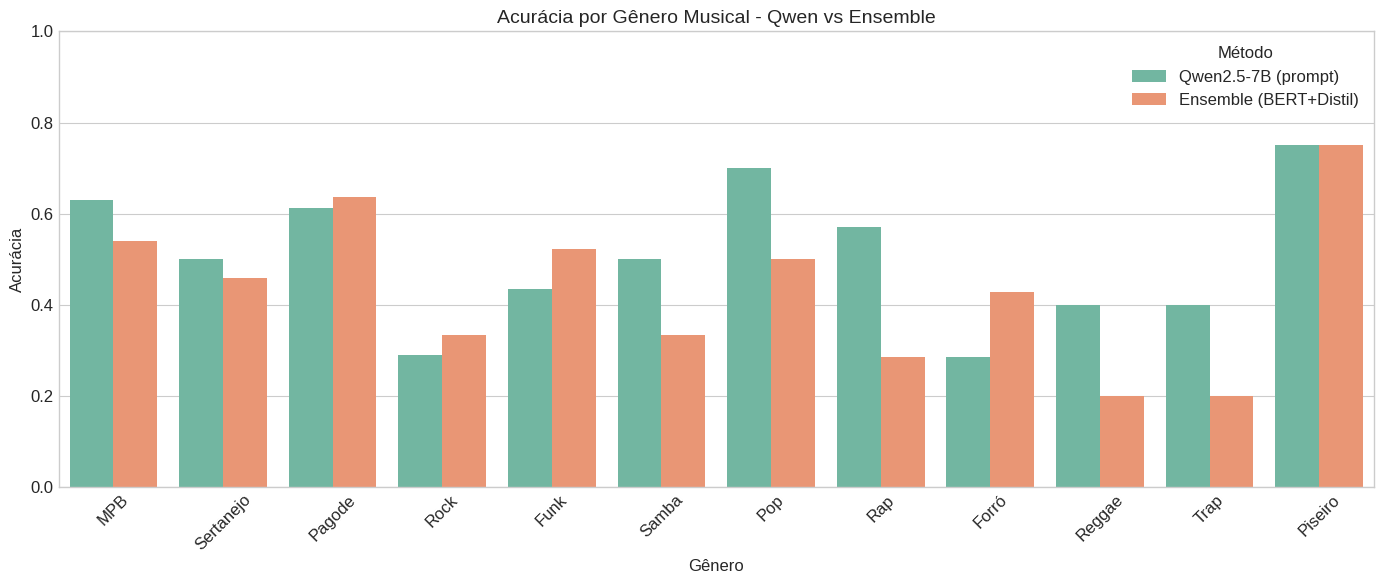

✅ Figuras salvas: fig_desempenho_por_genero.png/.pdf


In [44]:
# =====================================================
# 4. Análise por Gênero Musical (Qwen e Ensemble)
# =====================================================

# Carregar gênero do corpus
corpus_gen = pd.read_csv(CORPUS_CSV)[['id', 'genero']]
gold_gen = gold.merge(corpus_gen, on='id')

# Juntar com predições
df_gen = gold_gen[['id', 'emocao', 'genero']].copy()
for nome, col in METODOS.items():
    if nome in metodos_analise:
        df_gen = df_gen.merge(m[['id', col]], on='id', how='left')

# Calcular acurácia por gênero
result_gen = []
for nome in metodos_analise:
    col = METODOS[nome]
    for gen in df_gen['genero'].unique():
        sub = df_gen[df_gen['genero'] == gen].dropna(subset=[col])
        if len(sub) >= 3:  # mínimo para não distorcer
            acc = (sub['emocao'] == sub[col]).mean()
            result_gen.append({'método': nome, 'gênero': gen, 'acurácia': acc, 'n': len(sub)})

df_gen_plot = pd.DataFrame(result_gen)

# Ordenar por número de amostras
order = df_gen_plot[df_gen_plot['método'] == metodos_analise[0]].sort_values('n', ascending=False)['gênero']
df_gen_plot['gênero'] = pd.Categorical(df_gen_plot['gênero'], categories=order, ordered=True)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=df_gen_plot, x='gênero', y='acurácia', hue='método', ax=ax)
ax.set_title('Acurácia por Gênero Musical - Qwen vs Ensemble', fontsize=14)
ax.set_xlabel('Gênero')
ax.set_ylabel('Acurácia')
ax.set_ylim(0, 1)
ax.legend(title='Método')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_desempenho_por_genero.png', dpi=300, bbox_inches='tight')
plt.savefig('/kaggle/working/fig_desempenho_por_genero.pdf', bbox_inches='tight')
plt.show()
print("✅ Figuras salvas: fig_desempenho_por_genero.png/.pdf")

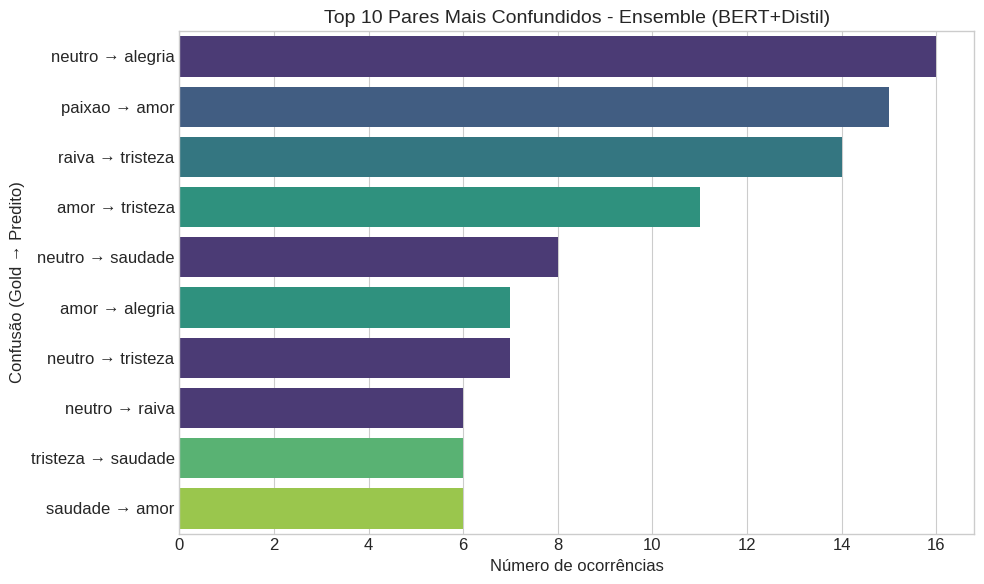

✅ Figuras salvas: fig_top_confusoes.png/.pdf


In [45]:
# =====================================================
# 5. Pares mais confundidos (Ensemble)
# =====================================================

# Escolha o método a analisar
metodo_escolhido = 'Ensemble (BERT+Distil)' if 'Ensemble (BERT+Distil)' in METODOS else 'Qwen2.5-7B (prompt)'
col = METODOS[metodo_escolhido]

sub = m.dropna(subset=[col])
cm = confusion_matrix(sub['emocao'], sub[col], labels=CLASSES)

# Extrair pares off-diagonal
confusos = []
for i, gold in enumerate(CLASSES):
    for j, pred in enumerate(CLASSES):
        if i != j and cm[i, j] > 0:
            confusos.append((gold, pred, cm[i, j]))

confusos.sort(key=lambda x: x[2], reverse=True)
top10 = confusos[:10]

df_conf = pd.DataFrame(top10, columns=['Gold', 'Predito', 'Contagem'])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_conf, y=df_conf['Gold'] + ' → ' + df_conf['Predito'], 
            x='Contagem', hue='Gold', palette='viridis', legend=False, ax=ax)
ax.set_title(f'Top 10 Pares Mais Confundidos - {metodo_escolhido}', fontsize=14)
ax.set_xlabel('Número de ocorrências')
ax.set_ylabel('Confusão (Gold → Predito)')
plt.tight_layout()
plt.savefig('/kaggle/working/fig_top_confusoes.png', dpi=300, bbox_inches='tight')
plt.savefig('/kaggle/working/fig_top_confusoes.pdf', bbox_inches='tight')
plt.show()
print("✅ Figuras salvas: fig_top_confusoes.png/.pdf")

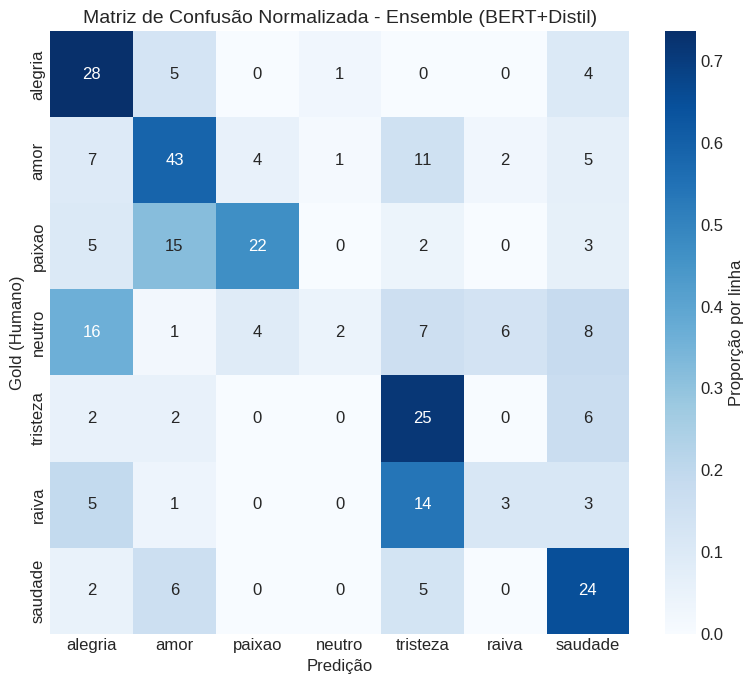

✅ Figuras salvas: fig_matriz_normalizada.png/.pdf


In [46]:
# =====================================================
# 5. Matriz de confusão normalizada por linha (aprimorada)
# =====================================================

metodo_escolhido = 'Ensemble (BERT+Distil)' if 'Ensemble (BERT+Distil)' in METODOS else 'Qwen2.5-7B (prompt)'
col = METODOS[metodo_escolhido]
sub = m.dropna(subset=[col])

cm = confusion_matrix(sub['emocao'], sub[col], labels=CLASSES)
cm_pct = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_pct, annot=cm, fmt='d', cmap='Blues', 
            xticklabels=CLASSES, yticklabels=CLASSES,
            cbar_kws={'label': 'Proporção por linha'}, ax=ax)
ax.set_title(f'Matriz de Confusão Normalizada - {metodo_escolhido}', fontsize=14)
ax.set_xlabel('Predição')
ax.set_ylabel('Gold (Humano)')
plt.tight_layout()
plt.savefig('/kaggle/working/fig_matriz_normalizada.png', dpi=300, bbox_inches='tight')
plt.savefig('/kaggle/working/fig_matriz_normalizada.pdf', bbox_inches='tight')
plt.show()
print("✅ Figuras salvas: fig_matriz_normalizada.png/.pdf")

=== ACURÁCIA POR POLARIDADE (Ensemble) ===
  polaridade_gold  acurácia_polaridade  total
0        Negativa             0.816327     98
1          Neutra             0.045455     44
2        Positiva             0.816456    158


/tmp/ipykernel_58/2533829222.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  polaridade_analysis = sub.groupby('polaridade_gold').apply(


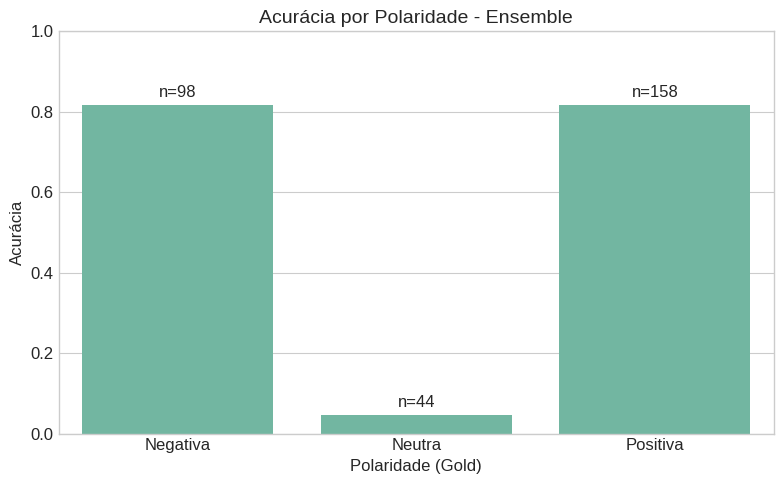

✅ Figuras salvas: fig_acuraria_por_polaridade.png/.pdf


In [47]:
# =====================================================
# 7. Distribuição de erros por polaridade (Ensemble)
# =====================================================

# Mapeamento de polaridade
polaridade_map = {
    'alegria': 'Positiva', 'amor': 'Positiva', 'paixao': 'Positiva',
    'neutro': 'Neutra',
    'tristeza': 'Negativa', 'raiva': 'Negativa', 'saudade': 'Negativa'
}

# Para o Ensemble
col_ens = METODOS.get('Ensemble (BERT+Distil)', None)
if col_ens is not None:
    sub = m.dropna(subset=[col_ens])
    sub['polaridade_gold'] = sub['emocao'].map(polaridade_map)
    sub['polaridade_pred'] = sub[col_ens].map(polaridade_map)
    
    # Contar acertos e erros por polaridade
    polaridade_analysis = sub.groupby('polaridade_gold').apply(
        lambda x: pd.Series({
            'total': len(x),
            'acertos': (x['polaridade_gold'] == x['polaridade_pred']).sum(),
            'erros': (x['polaridade_gold'] != x['polaridade_pred']).sum()
        })
    ).reset_index()
    polaridade_analysis['acurácia_polaridade'] = polaridade_analysis['acertos'] / polaridade_analysis['total']
    
    print("=== ACURÁCIA POR POLARIDADE (Ensemble) ===")
    print(polaridade_analysis[['polaridade_gold', 'acurácia_polaridade', 'total']].to_string())
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=polaridade_analysis, x='polaridade_gold', y='acurácia_polaridade', ax=ax)
    ax.set_title('Acurácia por Polaridade - Ensemble', fontsize=14)
    ax.set_xlabel('Polaridade (Gold)')
    ax.set_ylabel('Acurácia')
    ax.set_ylim(0, 1)
    for i, row in polaridade_analysis.iterrows():
        ax.text(i, row['acurácia_polaridade']+0.02, f"n={row['total']}", ha='center')
    plt.tight_layout()
    plt.savefig('/kaggle/working/fig_acuraria_por_polaridade.png', dpi=300, bbox_inches='tight')
    plt.savefig('/kaggle/working/fig_acuraria_por_polaridade.pdf', bbox_inches='tight')
    plt.show()
    print("✅ Figuras salvas: fig_acuraria_por_polaridade.png/.pdf")
else:
    print("⚠️ Ensemble não disponível; pule esta célula.")

In [48]:
# =====================================================
# 7. Sumário final das análises
# =====================================================

print("\n" + "="*60)
print("RESUMO DAS ANÁLISES COMPLEMENTARES")
print("="*60)
print(f"📊 Total de amostras no gold: {len(gold)}")
print(f"📊 Métodos analisados: {list(METODOS.keys())}")
print("📁 Arquivos gerados:")
print("  - metricas_detalhadas_por_classe.csv")
print("  - fig_macro_precision_recall_f1.png/.pdf")
print("  - fig_desempenho_por_decada.png/.pdf")
print("  - fig_desempenho_por_genero.png/.pdf")
print("  - fig_top_confusoes.png/.pdf")
print("  - fig_matriz_normalizada.png/.pdf")
print("  - fig_acuraria_por_polaridade.png/.pdf")
print("\n✅ Todas as análises concluídas com sucesso!")


RESUMO DAS ANÁLISES COMPLEMENTARES
📊 Total de amostras no gold: 7
📊 Métodos analisados: ['NRC (léxico)', 'Qwen2.5-7B (prompt)', 'BERTimbau (ft)', 'DistilBERT (ft)', 'Ensemble (BERT+Distil)']
📁 Arquivos gerados:
  - metricas_detalhadas_por_classe.csv
  - fig_macro_precision_recall_f1.png/.pdf
  - fig_desempenho_por_decada.png/.pdf
  - fig_desempenho_por_genero.png/.pdf
  - fig_top_confusoes.png/.pdf
  - fig_matriz_normalizada.png/.pdf
  - fig_acuraria_por_polaridade.png/.pdf

✅ Todas as análises concluídas com sucesso!
